# 이벤트 구조와 해석 기준
transcript 데이터는 고객별 이벤트 로그이며,\
received 이후 viewed, transaction, completed 이벤트가 발생할 수 있다.

- transaction은 반복 발생 가능하다.
- completed는 viewed 없이도 존재할 수 있다.
- 따라서 본 EDA의 핵심 전환은\
  received → viewed,\
  received → completed,\
  viewed → completed,\
  received → viewed → completed\
를 구분해 해석한다.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform
import matplotlib.pyplot as plt

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams[
        'font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


## 사용 함수

In [2]:
# 컬럼 정보 간단 표현
def check_basic_info(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 컬럼 정보 / 결측치 확인 정보 요약")
    print(f"{'='*80}\n")


    # 제외할 컬럼 반영
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # dict, list, set 같은 해시 불가능 값이 들어있는 컬럼은 문자열로 변환
    for col in df_copied.columns:
        try:
            df_copied[col].nunique(dropna=True)
        except TypeError:
            df_copied[col] = df_copied[col].astype(str)
    
    # 1. 전체 요약
    overview_df = pd.DataFrame({
        '항목': ['행 개수', '열 개수', '중복 행 개수'],
        '값': [df_copied.shape[0], df_copied.shape[1], df_copied.duplicated().sum()]
    })
    
    # 2. 컬럼별 요약
    summary_df = pd.DataFrame({
        '데이터타입': df_copied.dtypes.astype(str),
        '행 개수': df_copied.count(),
        '행 비율(%)': (df_copied.count() / len(df) * 100).round(2),
        '결측치 개수': df_copied.isnull().sum(),
        '결측치 비율(%)': (df_copied.isnull().sum() / len(df) * 100).round(2),
        '고유값 개수': df_copied.nunique(dropna=True)
    })
    
    # 3. 보기 좋게 정렬
    summary_df = summary_df.sort_values(
        by=['결측치 개수', '고유값 개수'],
        ascending=[False, False]
    )
    
    print("[전체 요약]")
    display(overview_df)
    
    print("[컬럼별 요약]")
    display(summary_df)

    print("[테이블 요약]")
    display(df.head())

In [3]:
# 컬럼 분포 확인
def check_category_summary(df, df_name, col_name):
    df_copied = df.copy()
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 {col_name} 범주 확인")
    print(f"{'='*80}")
    
    if col_name not in df_copied.columns:
        print(f"'{col_name}' 컬럼이 존재하지 않습니다.")
        return
    
    summary_df = df_copied[col_name].value_counts(dropna=False).reset_index()
    summary_df.columns = [col_name, '개수']
    summary_df['비율(%)'] = (summary_df['개수'] / len(df_copied) * 100).round(2)
    
    print("전체 행 수:", len(df_copied))
    print(f"{col_name} 고유값 개수(결측 포함):", df_copied[col_name].nunique(dropna=False))
    print()
    
    display(summary_df.head(10))

# 데이터 로드

In [4]:
# ============================================================
# 1. 원본 데이터 로드
# ============================================================
df = pd.read_csv("data/transcript_portfolio_profile.csv")

# 테이블 복제
df2 = df.copy()
check_basic_info(df2, 'transcript_portfolio')


transcript_portfolio의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,306137
1,열 개수,20
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
event_reward,float64,33182,10.84,272955,89.16,4
amount,float64,138953,45.39,167184,54.61,5103
offer_id,str,167184,54.61,138953,45.39,10
offer_reward,float64,167184,54.61,138953,45.39,5
difficulty,float64,167184,54.61,138953,45.39,5
duration,float64,167184,54.61,138953,45.39,5
channels,str,167184,54.61,138953,45.39,4
offer_type,str,167184,54.61,138953,45.39,3
web,float64,167184,54.61,138953,45.39,2
mobile,float64,167184,54.61,138953,45.39,2


[테이블 요약]


,customer_id,event,time,offer_id,amount,event_reward,offer_type,offer_reward,difficulty,duration,channels,web,email,mobile,social,gender,age,income,became_member_on,has_profile
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,bogo,5.0,5.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,F,75.0,100000.0,2017-05-09,1
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,discount,5.0,20.0,10.0,"['web', 'email']",1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,0
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,discount,2.0,10.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,M,68.0,70000.0,2018-04-26,1
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,discount,2.0,10.0,10.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,bogo,10.0,10.0,5.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0


In [18]:
# 이벤트별 구조적 결측깂

struct_missing_summary = (
    df2.groupby('event')[['offer_id', 'amount', 'event_reward']]
    .agg(lambda s: s.isna().sum())
)

display(struct_missing_summary)

,offer_id,amount,event_reward
event,,,
offer completed,0,33182,0
offer received,0,76277,76277
offer viewed,0,57725,57725
transaction,138953,0,138953


## 결측 해석 주의

데이터의 일부 결측은 데이터 오류가 아니라 이벤트 구조 차이에서 발생한 구조적 결측이다.

예를 들어,
- transaction 이벤트에서 offer_id가 없는 것은 정상이다.
- transaction이 아닌 이벤트에서 amount가 없는 것도 정상이다.
- offer completed가 아닌 이벤트에서 event_reward가 없는 것도 정상이다.

따라서 결측은 일괄적으로 데이터 품질 문제로 해석하지 않고,\
이벤트 구조에 따른 정상 결측과 실제 미매칭 결측을 구분해 봐야 한다.

# 전환율 테이블 생성

이 분석에선 전환율은 received를 기준으로 viewed, completed 반응을 연결해 계산한다.

- viewed, completed는 반드시 offer의 duration(유효기간) 내에서 발생한 경우만 유효 반응으로 인정한다.
- duration을 고려하지 않으면 오퍼 반응률과 완료율이 과대 또는 왜곡될 수 있다.
- transaction은 특정 offer와 직접 연결되지 않으므로, 본 분석에서는 프로모션 직접 성과 지표로써 사용하지 않는다.

시간 순서를 고려해\
고객 세그먼트, reward, difficulty, channel, offer_type 같은 변수와 붙여 분석한다.

## received / completed 이벤트 분리
전환율의 분모와 분자 생성

In [7]:
# ============================================================
# received / viewed / completed 이벤트 분리
# ============================================================
# received 분리
received = (
    df2[df2['event'] == 'offer received'][
        [
            'customer_id', 'offer_id', 'time',
            'offer_type', 'offer_reward', 'difficulty', 'duration',
            'web', 'email', 'mobile', 'social'
        ]
    ]
    .copy()
    .rename(columns={'time': 'time_received'})
)

# viewed 분리
viewed = (
    df2[df2['event'] == 'offer viewed'][
        ['customer_id', 'offer_id', 'time']
    ]
    .copy()
    .rename(columns={'time': 'time_viewed'})
)

# completed 분리
completed = (
    df2[df2['event'] == 'offer completed'][
        ['customer_id', 'offer_id', 'time']
    ]
    .copy()
    .rename(columns={'time': 'time_completed'})
)

print("received 행 수:", len(received))
print("viewed 행 수:", len(viewed))
print("completed 행 수:", len(completed))

received 행 수: 76277
viewed 행 수: 57725
completed 행 수: 33182


## 시간순 정렬과 반응 단위 정의
동일 고객이 동일 offer를 여러 번 받을 수 있으므로,\
(customer_id + offer_id) 조합만으로는 하나의 고유 반응 단위를 정의할 수 없다.

따라서 본 분석에서는 received 이벤트 1건을 하나의 반응 단위(instance처럼)로 보고,\
이후 발생한 viewed, completed를 시간 순서와 duration 조건에 맞게 연결한다.

원래는 seq 방식으로 n번째 received와 n번째 completed를 연결하고자 했으나,\
같은 고객이 같은 오퍼를 이전 오퍼 유효기간이 끝나기 전에 또 받은 경우\
잘못 연결될 가능성이 있어 방식 변경이 필요했다.

그래서 completed보다 먼저 발생한 received만 후보로 보고,\
그중 가장 최근의 유효한 received를 연결하는 구조로 정의하였다.

추가적으로 생성하는 시간 컬럼
- time_completed_rc : received → completed용 completed 시간
- time_completed_vc : viewed → completed용 completed 시간

플래그 컬럼
- converted_rv : received → viewed
- converted_rc : received → completed
- converted_vc : viewed → completed
- converted_rvc : received → viewed → completed


조건에 맞는 received가 없으면 해당 completed는 연결하지 않는다.\
즉, completed는 존재하더라도 유효한 received와 연결되지 않으면 분석용 match_df에는 포함되지 않는다.

In [8]:
# ============================================================
# 정렬 + 기준키 생성
# ============================================================
received = received.sort_values(
    ["customer_id", "offer_id", "time_received"]
).reset_index(drop=True)

viewed = viewed.sort_values(
    ["customer_id", "offer_id", "time_viewed"]
).reset_index(drop=True)

completed = completed.sort_values(
    ["customer_id", "offer_id", "time_completed"]
).reset_index(drop=True)

# received 기준 고유 행 번호 만들기
received["received_idx"] = received.index

# 오퍼 유효 종료 시점
received["offer_end_time"] = received["time_received"] + received["duration"] * 24

In [9]:
# ============================================================
# 공통 매칭 함수
# - event를 가장 최근의 유효한 base 이벤트에 연결
# - 시간 순서 맞게
# - duration 안의 이벤트만 인정
# - 1대1방식으로 (한 base는 같은 방식에서 1번만 사용)
# - 속도 개선 버전
# ============================================================
def match_event_to_base(
        base_df,           # 기준이 되는 이벤트 테이블(received 또는 viewed)
        event_df,          # base에 연결할 이벤트 테이블(viewed 또는 completed)
        base_time_col,     # base 이벤트의 시간 컬럼명
        event_time_col,    # 연결할 event의 시간 컬럼명
        matched_time_col,  # 매칭 후 result에 새로 붙일 시간 컬럼명
        base_id_col="received_idx"  # base 행을 구분하는 고유 식별 컬럼명
        ):
    """
    received 또는 viewed를 기준으로 잡고 그 뒤에 일어난 viewed/completed를
    같은 고객과 같은 오퍼 안에서 가장 최근의 유효한 base에 1대1로 연결
    """
    
    # 매칭 결과를 저장할 리스트
    match_rows = []

    # base 이벤트(received 또는 viewed?) 고객, 오퍼, 시간 순서대로 정렬
    # -> 불필요한 컬럼을 줄여서 속도와 메모리 사용을 줄임
    base_sorted = (
        base_df[["customer_id", "offer_id", base_id_col, base_time_col, "offer_end_time"]]
        .sort_values(["customer_id", "offer_id", base_time_col])
        .reset_index(drop=True)
    )

    # event 이벤트(viewed 또는 completed) 고객, 오퍼, 시간 순서대로 정렬
    # 이벤트 발생 순서대로 base와 연결
    event_sorted = (
        event_df[["customer_id", "offer_id", event_time_col]]
        .sort_values(["customer_id", "offer_id", event_time_col])
        .reset_index(drop=True)
    )

    # base를 customer_id + offer_id 그룹별로 한 번만 저장
    # -> 반복문 안에서 base_group을 계속 다시 찾지 않기 위함
    # -> numpy 배열로 바꿔서 더 빠르게 처리
    base_groups = {
        key: group[[base_id_col, base_time_col, "offer_end_time"]].to_numpy()
        for key, group in base_sorted.groupby(["customer_id", "offer_id"], sort=False)
    }

    # event를 customer_id + offer_id 단위로 묶어서 반복
    for key, event_group in event_sorted.groupby(["customer_id", "offer_id"], sort=False):

        # 현재 그룹에 해당하는 base 가져오기
        bases = base_groups.get(key)

        # 해당 고객+오퍼의 base가 아예 없으면 다음 그룹으로
        if bases is None:
            continue

        # numpy 배열에서 필요한 값 분리
        # base_ids        : base 행의 고유 식별값
        # base_times      : base 발생 시간
        # offer_end_times : 각 base의 유효 종료 시점
        base_ids = bases[:, 0]
        base_times = bases[:, 1].astype(float)
        offer_end_times = bases[:, 2].astype(float)

        # 같은 방식에서 한 base는 1번만 사용
        # -> 이미 사용한 base는 True로 바뀜
        used = np.zeros(len(bases), dtype=bool)

        # event 발생 시간을 하나씩 확인하면서 조건에 맞는 base 찾기
        for event_time in event_group[event_time_col].to_numpy(dtype=float):

            # event_time 이하인 base 중
            # 가장 최근 base 위치를 빠르게 찾음
            # -> searchsorted는 정렬된 배열에서 위치를 빠르게 찾는 함수
            j = np.searchsorted(base_times, event_time, side="right") - 1

            # 가장 최근 후보부터 뒤에서 앞으로 확인
            # -> event와 가장 가까운 이전 base를 선택하기 위함
            while j >= 0:

                # 조건 1 아직 사용되지 않은 base인가?
                # 조건 2 event가 offer_end_time 이내인가?
                # -> duration 안에서 일어난 이벤트만 인정
                if (not used[j]) and (offer_end_times[j] >= event_time):
                    match_rows.append({
                        base_id_col: base_ids[j],
                        matched_time_col: event_time
                    })

                    # 사용한 base는 다시 못 쓰게 저장
                    used[j] = True
                    break

                # 조건이 안 맞으면 더 이전 base를 확인
                j -= 1

    # 최종 결과는 base_df를 기준으로 유지
    result = base_df.copy()

    # 매칭 결과가 하나도 없으면 결측치로 만든 뒤 반환
    if not match_rows:
        result[matched_time_col] = pd.NA
        return result

    # 매칭 결과 리스트를 DataFrame으로 변환
    match_df = pd.DataFrame(match_rows)

    # base_df와 매칭 결과를 base_id_col 기준으로 왼쪽 병합
    # -> 매칭 성공한 행은 시간값이 붙고
    # -> 실패한 행은 NaN으로 남음
    result = result.merge(
        match_df,
        on=base_id_col,
        how="left"
    )

    return result

## 4개 전환 기준 테이블 생성

In [10]:
# ============================================================
# 1) received -> viewed 매칭
# ============================================================
rv = match_event_to_base(
    base_df=received,                 # 기준: 받은 오퍼(received)
    event_df=viewed,                  # 연결 대상: 열람 이벤트(viewed)
    base_time_col="time_received",    # 기준 시간: 오퍼 받은 시점
    event_time_col="time_viewed",     # 연결할 이벤트 시간: 오퍼 본 시점
    matched_time_col="time_viewed"    # 결과로 붙일 컬럼명
)

In [11]:
# ============================================================
# 2) received -> completed 매칭
# ============================================================
rc_match = match_event_to_base(
    base_df=received,                    # 기준: 받은 오퍼(received)
    event_df=completed,                  # 연결 대상: 완료 이벤트(completed)
    base_time_col="time_received",       # 기준 시간: 오퍼 받은 시점
    event_time_col="time_completed",     # 연결할 이벤트 시간: 오퍼 완료 시점
    matched_time_col="time_completed_rc" # 결과로 붙일 컬럼명(received→completed용)
)


In [12]:
# ============================================================
# 3) viewed -> completed 매칭
# viewed가 붙은 received만 대상으로, viewed 이후 completed를 다시 매칭
# ============================================================
view_base = rv[rv["time_viewed"].notna()].copy()

vc_match = match_event_to_base(
    base_df=view_base,                  # 기준: viewed가 확인된 received
    event_df=completed,                 # 연결 대상: 완료 이벤트(completed)
    base_time_col="time_viewed",        # 기준 시간: 오퍼 본 시점
    event_time_col="time_completed",    # 연결할 이벤트 시간: 오퍼 완료 시점
    matched_time_col="time_completed_vc" # 결과로 붙일 컬럼명(viewed→completed용)
)

In [13]:
# ============================================================
# 최종 received 기준 퍼널 테이블 생성
# ============================================================
funnel = received.copy()

# received -> viewed 매칭 결과 붙이기
funnel = funnel.merge(
    rv[["received_idx", "time_viewed"]],
    on="received_idx",
    how="left"
)

# received -> completed 매칭 결과 붙이기
funnel = funnel.merge(
    rc_match[["received_idx", "time_completed_rc"]],
    on="received_idx",
    how="left"
)

# 시간 차이 계산
# 각 단계까지 걸린 시간을 계산
funnel = funnel.merge(
    vc_match[["received_idx", "time_completed_vc"]],
    on="received_idx",
    how="left"
)

# 시간 차이
funnel["rv_time_diff"] = funnel["time_viewed"] - funnel["time_received"]
funnel["rc_time_diff"] = funnel["time_completed_rc"] - funnel["time_received"]
funnel["vc_time_diff"] = funnel["time_completed_vc"] - funnel["time_viewed"]

# 유효 여부 플래그
# 시간값이 존재하면 1, 없으면 0으로 변환
funnel["has_viewed"] = funnel["time_viewed"].notna().astype(int)
funnel["has_completed_rc"] = funnel["time_completed_rc"].notna().astype(int)
funnel["has_completed_after_view"] = funnel["time_completed_vc"].notna().astype(int)

# 전환 플래그
# converted_rv  : received -> viewed 전환 여부
funnel["converted_rv"] = funnel["has_viewed"]

# converted_rc  : received -> completed 전환 여부
funnel["converted_rc"] = funnel["has_completed_rc"]

# converted_vc  : viewed -> completed 전환 여부
funnel["converted_vc"] = funnel["has_completed_after_view"]

# converted_rvc : received -> viewed -> completed 전환 여부
funnel["converted_rvc"] = (
    (funnel["has_viewed"] == 1) &
    (funnel["has_completed_after_view"] == 1)
).astype(int)

# 기존 코드 호환용
# 기존 converted_final 의미를 유지하려면 received -> completed로 둠
funnel["converted_final"] = funnel["converted_rc"]

In [14]:
# ------------------------------------------------------------
# 퍼널 분석에 필요한 핵심 컬럼만 선택해서 최종 테이블 형태로 정리
# ------------------------------------------------------------
funnel = funnel[
    [
        'customer_id', 'offer_id',                          # 고객 / 오퍼 식별 정보
        'offer_type', 'offer_reward', 'difficulty', 'duration',   # 오퍼 속성 정보
        'web', 'email', 'mobile', 'social',                # 오퍼 발송 채널 정보

        'time_received', 'offer_end_time',                 # 오퍼 수신 시점 / 오퍼 유효 종료 시점
        'time_viewed', 'time_completed_rc', 'time_completed_vc',   # 단계별 매칭 시간 정보

        'rv_time_diff', 'rc_time_diff', 'vc_time_diff',    # 단계별 소요 시간 정보

        'has_viewed', 'has_completed_rc', 'has_completed_after_view',  # 이벤트 연결 여부 플래그

        'converted_rv', 'converted_rc', 'converted_vc', 'converted_rvc', # 전환 여부 플래그
        'converted_final'                                  # 기존 코드 호환용 최종 전환 컬럼
    ]
].copy()

# ------------------------------------------------------------
# 최종 funnel 테이블의 기본 정보(행/열 수, 결측치, 타입 등) 확인
# ------------------------------------------------------------
check_basic_info(funnel, 'received 기준 funnel 테이블')


received 기준 funnel 테이블의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,76277
1,열 개수,26
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
time_completed_vc,float64,23496,30.80,52781,69.20,120
vc_time_diff,float64,23496,30.80,52781,69.20,41
time_completed_rc,float64,33152,43.46,43125,56.54,120
rc_time_diff,float64,33152,43.46,43125,56.54,41
time_viewed,float64,56567,74.16,19710,25.84,120
rv_time_diff,float64,56567,74.16,19710,25.84,41
customer_id,str,76277,100.00,0,0.00,16994
offer_end_time,float64,76277,100.00,0,0.00,22
offer_id,str,76277,100.00,0,0.00,10
time_received,int64,76277,100.00,0,0.00,6


[테이블 요약]


,customer_id,offer_id,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,time_received,offer_end_time,time_viewed,time_completed_rc,time_completed_vc,rv_time_diff,rc_time_diff,vc_time_diff,has_viewed,has_completed_rc,has_completed_after_view,converted_rv,converted_rc,converted_vc,converted_rvc,converted_final
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,2.0,10.0,7.0,1.0,1.0,1.0,0.0,576,744.0,NaN,576.0,NaN,NaN,0.0,NaN,0,1,0,0,1,0,0,1
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational,0.0,0.0,4.0,1.0,1.0,1.0,0.0,336,432.0,372.0,NaN,NaN,36.0,NaN,NaN,1,0,0,1,0,0,0,0
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational,0.0,0.0,3.0,0.0,1.0,1.0,1.0,168,240.0,192.0,NaN,NaN,24.0,NaN,NaN,1,0,0,1,0,0,0,0
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,408,528.0,456.0,414.0,NaN,48.0,6.0,NaN,1,1,0,1,1,0,0,1
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,1.0,1.0,1.0,1.0,504,744.0,540.0,528.0,NaN,36.0,24.0,NaN,1,1,0,1,1,0,0,1


## 완성물 해설


- customer_id               : 고객 식별 ID
- offer_id                  : 오퍼 식별 ID

- offer_type                : 오퍼 유형(bogo, discount, informational 등)
- offer_reward              : 오퍼 보상값
- difficulty                : 오퍼 완료 조건 금액/난이도
- duration                  : 오퍼 유효기간(일 단위)

- web                       : 웹 채널 발송 여부
- email                     : 이메일 채널 발송 여부
- mobile                    : 모바일 채널 발송 여부
- social                    : 소셜 채널 발송 여부

- time_received             : 오퍼를 받은 시점
- offer_end_time            : 오퍼 유효 종료 시점(time_received + duration*24)
- time_viewed               : received 이후 매칭된 viewed 시점
- time_completed_rc         : received 이후 매칭된 completed 시점
- time_completed_vc         : viewed 이후 매칭된 completed 시점

- rv_time_diff              : received 후 viewed까지 걸린 시간
- rc_time_diff              : received 후 completed까지 걸린 시간
- vc_time_diff              : viewed 후 completed까지 걸린 시간

- has_viewed                : viewed 매칭 여부(있으면 1, 없으면 0)
- has_completed_rc          : received 기준 completed 매칭 여부(있으면 1, 없으면 0)
- has_completed_after_view  : viewed 기준 completed 매칭 여부(있으면 1, 없으면 0)

- converted_rv              : received -> viewed 전환 여부 : 열람률
- converted_rc              : received -> completed 전환 여부 : 전체 완료율
- converted_vc              : viewed -> completed 전환 여부 : 열람 후 완료율
- converted_rvc             : received -> viewed -> completed 전환 여부 : 정상 퍼널 완료율

- converted_final           : 기존 코드 호환용 최종 전환 컬럼(received -> completed 기준)

In [15]:
# 오퍼 반응 퍼널 분석에 필요한 핵심 컬럼만 선별
# 식별자, 오퍼 속성, 채널, 기준 시점, 시간차, 전환 여부 중심으로 구성
funnel_clean = funnel[
    [
        'customer_id',      # 고객 식별 ID
        'offer_id',         # 오퍼 식별 ID

        'offer_type',       # 오퍼 유형(bogo, discount, informational 등)
        'offer_reward',     # 오퍼 보상값
        'difficulty',       # 오퍼 완료 조건 금액/난이도
        'duration',         # 오퍼 유효기간(일 단위)

        'web',              # 웹 채널 발송 여부
        'email',            # 이메일 채널 발송 여부
        'mobile',           # 모바일 채널 발송 여부
        'social',           # 소셜 채널 발송 여부

        'time_received',    # 오퍼를 받은 시점
        'offer_end_time',   # 오퍼 유효 종료 시점(time_received + duration*24)

        'rv_time_diff',     # received 후 viewed까지 걸린 시간
        'rc_time_diff',     # received 후 completed까지 걸린 시간
        'vc_time_diff',     # viewed 후 completed까지 걸린 시간

        'converted_rv',     # received -> viewed 전환 여부
        'converted_rc',     # received -> completed 전환 여부
        'converted_vc',     # viewed -> completed 전환 여부
        'converted_rvc'     # received -> viewed -> completed 전환 여부
    ]
].copy()

# converted_final
# 기존 코드 호환용 컬럼으로, converted_rc와 의미가 겹쳐 제외

# has_viewed, has_completed_rc, has_completed_after_view
# 매칭 여부 컬럼이지만 rv, rc, vc가  더 직관적으로 보여주므로 제외

# time_viewed, time_completed_rc, time_completed_vc
# 상세 시점 확인용 컬럼

# 고객 세그먼트 변수(age, gender, income, became_member_on)는 추후 필요 시 merge

check_basic_info(funnel_clean, ' funnel_clean 테이블')


 funnel_clean 테이블의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,76277
1,열 개수,19
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
vc_time_diff,float64,23496,30.80,52781,69.20,41
rc_time_diff,float64,33152,43.46,43125,56.54,41
rv_time_diff,float64,56567,74.16,19710,25.84,41
customer_id,str,76277,100.00,0,0.00,16994
offer_end_time,float64,76277,100.00,0,0.00,22
offer_id,str,76277,100.00,0,0.00,10
time_received,int64,76277,100.00,0,0.00,6
offer_reward,float64,76277,100.00,0,0.00,5
difficulty,float64,76277,100.00,0,0.00,5
duration,float64,76277,100.00,0,0.00,5


[테이블 요약]


,customer_id,offer_id,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,time_received,offer_end_time,rv_time_diff,rc_time_diff,vc_time_diff,converted_rv,converted_rc,converted_vc,converted_rvc
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,2.0,10.0,7.0,1.0,1.0,1.0,0.0,576,744.0,NaN,0.0,NaN,0,1,0,0
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational,0.0,0.0,4.0,1.0,1.0,1.0,0.0,336,432.0,36.0,NaN,NaN,1,0,0,0
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational,0.0,0.0,3.0,0.0,1.0,1.0,1.0,168,240.0,24.0,NaN,NaN,1,0,0,0
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,408,528.0,48.0,6.0,NaN,1,1,0,0
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,1.0,1.0,1.0,1.0,504,744.0,36.0,24.0,NaN,1,1,0,0


## 검증단계

In [16]:
print("=" * 80)
print("기본 검증단계")
print("=" * 80)

received_count = len(funnel_clean)
viewed_count = funnel_clean["converted_rv"].sum()
completed_rc_count = funnel_clean["converted_rc"].sum()
completed_vc_count = funnel_clean["converted_vc"].sum()
strict_funnel_count = funnel_clean["converted_rvc"].sum()

rv_rate = viewed_count / received_count * 100 if received_count > 0 else 0
rc_rate = completed_rc_count / received_count * 100 if received_count > 0 else 0
vc_rate = completed_vc_count / viewed_count * 100 if viewed_count > 0 else 0
rvc_rate = strict_funnel_count / received_count * 100 if received_count > 0 else 0

print("received 기준 전체 건수:", received_count)
print("viewed가 붙은 건수:", viewed_count)
print("completed(received 기준)가 붙은 건수:", completed_rc_count)
print("completed(viewed 기준)가 붙은 건수:", completed_vc_count)
print("strict funnel 완료 건수:", strict_funnel_count)
print()

print("received → viewed 전환율:", round(rv_rate, 2), "%")
print("received → completed 전환율:", round(rc_rate, 2), "%")
print("viewed → completed 전환율:", round(vc_rate, 2), "%")
print("received → viewed → completed 전환율:", round(rvc_rate, 2), "%")

기본 검증단계
received 기준 전체 건수: 76277
viewed가 붙은 건수: 56567
completed(received 기준)가 붙은 건수: 33152
completed(viewed 기준)가 붙은 건수: 23496
strict funnel 완료 건수: 23496

received → viewed 전환율: 74.16 %
received → completed 전환율: 43.46 %
viewed → completed 전환율: 41.54 %
received → viewed → completed 전환율: 30.8 %


In [17]:
# ============================================================
# completed 해석 보강 검증
# - viewed 없이 completed가 있는지
# - viewed가 있어도 completed보다 늦은 경우가 있는지 확인
# ============================================================

completed_mask = funnel['time_completed_rc'].notna()
strict_mask = funnel['time_completed_vc'].notna()

completed_no_view = completed_mask & funnel['time_viewed'].isna()
completed_before_view = (
    completed_mask &
    funnel['time_viewed'].notna() &
    (funnel['time_completed_rc'] < funnel['time_viewed'])
)

completed_case_summary = pd.DataFrame({
    '구분': [
        'received 기준 completed 전체',
        'strict funnel completed',
        'viewed 없이 completed',
        'viewed는 있으나 completed가 더 빠른 경우'
    ],
    '건수': [
        completed_mask.sum(),
        strict_mask.sum(),
        completed_no_view.sum(),
        completed_before_view.sum()
    ]
})

completed_case_summary['비율(%)'] = (
    completed_case_summary['건수'] /
    completed_mask.sum() * 100
).round(2)

display(completed_case_summary)

,구분,건수,비율(%)
0,received 기준 completed 전체,33152,100.00
1,strict funnel completed,23496,70.87
2,viewed 없이 completed,5744,17.33
3,viewed는 있으나 completed가 더 빠른 경우,4105,12.38


completed는 항상 viewed 이후에만 발생하는 것이 아니며,\
실 데이터에서는 viewed 없이 completed가 존재하거나,\
viewed가 있어도 completed가 더 먼저 매칭되는 케이스가 확인된다.

따라서 앞으로의 분석에선 completed는 하나로 뭉뚱그려 해석하지 않고,
- received → completed
- viewed → completed
- received → viewed → completed

를 구분해 해석한다.

# 주의 
- transaction은 특정 offer와 직접 매핑되지 않으므로 프로모션의 직접 성과로 해석하지 않는다.
- 따라서 transaction은 참고 가능한 구매 행동 이벤트로만 보고, 핵심 전환은 received, viewed, completed를 기준으로 해석한다.
- 또한 모든 viewed, completed 반응은 duration(유효기간) 내 발생한 경우만 유효한 반응으로 인정한다.

# 분석 내용

1. 어떤 고객 세그먼트가 어떤 프로모션에 더 잘 반응하는가(열람)?
2. 채널 조합에 따라 오퍼 반응률은 어떻게 달라지는가?
3. 어떤 고객군이 오퍼를 본 뒤 완료까지 더 잘 이어지는가?
4. 어떤 프로모션 유형이 열람률·완료율 측면에서 더 성과가 좋은가?
5. 유형별 세부 오퍼 비교

# 1. 어떤 고객 세그먼트가 어떤 프로모션에 더 잘 반응하는가(열람)?
고객 특성에 따라 어떤 프로모션 유형에 더 잘 반응하는가?

- 고객 세그먼트 종류
    - gender
    - age
    - income
    - became_member_on

- 사용 지표
    - `converted_rv` : 오퍼를 받은 뒤 실제로 열람했는가
    - `rv_rate` : received 대비 viewed 비율

## 1. 고객 세그먼트 컬럼 생성

In [24]:
# 1. 고객 세그먼트 정보 준비

# 고객 기준 프로필 정보만 추출
profile_base = (
    df2[[
        'customer_id', 
        'gender',
        'age', 
        'income', 
        'became_member_on']]
    .drop_duplicates(subset=['customer_id'])
    .copy()
)
print("profile_base 고객 수:", profile_base['customer_id'].nunique())

# funnel_clean에 고객 세그먼트 정보 붙이기
funnel_seg = funnel_clean.merge(
    profile_base,
    on='customer_id',
    how='left'
)

print("funnel_seg 행 수:", len(funnel_seg))
print("funnel_seg 고객 수:", funnel_seg['customer_id'].nunique())
display(funnel_seg.head())

profile_base 고객 수: 17000
funnel_seg 행 수: 76277
funnel_seg 고객 수: 16994


,customer_id,offer_id,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,time_received,offer_end_time,rv_time_diff,rc_time_diff,vc_time_diff,converted_rv,converted_rc,converted_vc,converted_rvc,gender,age,income,became_member_on
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,2.0,10.0,7.0,1.0,1.0,1.0,0.0,576,744.0,NaN,0.0,NaN,0,1,0,0,M,33.0,72000.0,2017-04-21
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational,0.0,0.0,4.0,1.0,1.0,1.0,0.0,336,432.0,36.0,NaN,NaN,1,0,0,0,M,33.0,72000.0,2017-04-21
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational,0.0,0.0,3.0,0.0,1.0,1.0,1.0,168,240.0,24.0,NaN,NaN,1,0,0,0,M,33.0,72000.0,2017-04-21
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,408,528.0,48.0,6.0,NaN,1,1,0,0,M,33.0,72000.0,2017-04-21
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,1.0,1.0,1.0,1.0,504,744.0,36.0,24.0,NaN,1,1,0,0,M,33.0,72000.0,2017-04-21


In [25]:
# ============================================================
# profile 전체 고객과 funnel 기준 고객 비교
# ============================================================
all_profile_customers = set(profile_base['customer_id'])
funnel_customers = set(funnel_clean['customer_id'])

missing_customers = sorted(all_profile_customers - funnel_customers)

print("profile 전체 고객 수:", len(all_profile_customers))
print("funnel 고객 수:", len(funnel_customers))
print("빠진 고객 수:", len(missing_customers))

# 빠진 고객들의 transcript 이벤트 확인
missing_event_check = (
    df2[df2['customer_id'].isin(missing_customers)]
    .groupby(['customer_id', 'event'])
    .size()
    .reset_index(name='count')
    .sort_values(['customer_id', 'event'])
)

display(missing_event_check)

profile 전체 고객 수: 17000
funnel 고객 수: 16994
빠진 고객 수: 6


,customer_id,event,count
0,12ede229379747bd8d74ccdc20097ca3,transaction,3
1,3a4874d8f0ef42b9a1b72294902afea9,transaction,3
2,ae8111e7e8cd4b60a8d35c42c1110555,transaction,5
3,c6e579c6821c41d1a7a6a9cf936e91bb,transaction,4
4,da7a7c0dcfcb41a8acc7864a53cf60fb,transaction,1
5,eb540099db834cf59001f83a4561aef3,transaction,4


고객수가 6명 빠진 이유?
- profile에는 있는데 received 기준 퍼널(funnel_clean)에는 한 번도 들어오지 않은 고객
- 즉, 전체 고객 17,000명 중 6명은 아예 offer received 이벤트가 없었다

## 2. 세그먼트 그룹핑

1. gender_group
    - F
    - M
    - O
    - Missing

2. age_group
    - 18-29
    - 30-39
    - 40-49
    - 50-59
    - 60-69
    - 70+
    - Missing

3. income_group
    - 30k-49k
    - 50k-69k
    - 70k-89k
    - 90k+
    - Missing

4. member_cohort
    - 2013~2014
    - 2015~2016
    - 2017~2018
    - Missing

In [26]:
funnel_seg = funnel_seg.copy()

# ======================================================================================
# 1. gender_group
funnel_seg['gender_group'] = (
    funnel_seg['gender']
    .fillna('Missing')
)
# ======================================================================================

# ======================================================================================
# 2. age_group
funnel_seg['age_clean'] = (
    funnel_seg['age']
    .where(
        funnel_seg['age']
        .between(18, 100),pd.NA)
)

funnel_seg['age_group'] = pd.cut(
    funnel_seg['age_clean'],
    bins=[18, 30, 40, 50, 60, 70, float('inf')],
    right=False,
    labels=['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
)

funnel_seg['age_group'] = funnel_seg['age_group'].astype('object').fillna('Missing')
# ======================================================================================

# ======================================================================================
# 3. income_group
funnel_seg['income_group'] = pd.cut(
    funnel_seg['income'],
    bins=[30000, 50000, 70000, 90000, float('inf')],
    right=False,
    labels=['30k-49k', '50k-69k', '70k-89k', '90k+']
)

funnel_seg['income_group'] = funnel_seg['income_group'].astype('object').fillna('Missing')
# ======================================================================================

# ======================================================================================
# 4. member_cohort
funnel_seg['became_member_on'] = funnel_seg['became_member_on'].astype('string')
funnel_seg['member_year'] = pd.to_numeric(
    funnel_seg['became_member_on'].str[:4],
    errors='coerce'
)

funnel_seg['member_cohort'] = pd.cut(
    funnel_seg['member_year'],
    bins=[2013, 2015, 2017, 2019],
    right=False,
    labels=['2013-2014', '2015-2016', '2017-2018']
)

funnel_seg['member_cohort'] = funnel_seg['member_cohort'].astype('object').fillna('Missing')
# ======================================================================================

# 최종확인
display(
    funnel_seg[
        [
            'customer_id', 'gender', 'gender_group',
            'age', 'age_group',
            'income', 'income_group',
            'became_member_on', 'member_year', 'member_cohort'
        ]
    ].head(10)
)

,customer_id,gender,gender_group,age,age_group,income,income_group,became_member_on,member_year,member_cohort
0,0009655768c64bdeb2e877511632db8f,M,M,33.0,30-39,72000.0,70k-89k,2017-04-21,2017,2017-2018
1,0009655768c64bdeb2e877511632db8f,M,M,33.0,30-39,72000.0,70k-89k,2017-04-21,2017,2017-2018
2,0009655768c64bdeb2e877511632db8f,M,M,33.0,30-39,72000.0,70k-89k,2017-04-21,2017,2017-2018
3,0009655768c64bdeb2e877511632db8f,M,M,33.0,30-39,72000.0,70k-89k,2017-04-21,2017,2017-2018
4,0009655768c64bdeb2e877511632db8f,M,M,33.0,30-39,72000.0,70k-89k,2017-04-21,2017,2017-2018
5,00116118485d4dfda04fdbaba9a87b5c,NaN,Missing,NaN,Missing,NaN,Missing,<NA>,<NA>,Missing
6,00116118485d4dfda04fdbaba9a87b5c,NaN,Missing,NaN,Missing,NaN,Missing,<NA>,<NA>,Missing
7,0011e0d4e6b944f998e987f904e8c1e5,O,O,40.0,40-49,57000.0,50k-69k,2018-01-09,2018,2017-2018
8,0011e0d4e6b944f998e987f904e8c1e5,O,O,40.0,40-49,57000.0,50k-69k,2018-01-09,2018,2017-2018
9,0011e0d4e6b944f998e987f904e8c1e5,O,O,40.0,40-49,57000.0,50k-69k,2018-01-09,2018,2017-2018


## 3. 세그멘트별 기본 분포 확인

In [27]:
# ============================================================
# 세그먼트별 기본 분포 확인
# ============================================================
check_category_summary(funnel_seg, "funnel_seg", 'gender_group')
check_category_summary(funnel_seg, "funnel_seg", 'age_group')
check_category_summary(funnel_seg, "funnel_seg", 'income_group')
check_category_summary(funnel_seg, "funnel_seg", 'member_cohort')



funnel_seg의 gender_group 범주 확인
전체 행 수: 76277
gender_group 고유값 개수(결측 포함): 4



,gender_group,개수,비율(%)
0,M,38129,49.99
1,F,27456,36.00
2,Missing,9776,12.82
3,O,916,1.20



funnel_seg의 age_group 범주 확인
전체 행 수: 76277
age_group 고유값 개수(결측 포함): 7



,age_group,개수,비율(%)
0,50-59,15894,20.84
1,60-69,13423,17.60
2,70+,12885,16.89
3,40-49,10288,13.49
4,Missing,9799,12.85
5,18-29,7095,9.30
6,30-39,6893,9.04



funnel_seg의 income_group 범주 확인
전체 행 수: 76277
income_group 고유값 개수(결측 포함): 5



,income_group,개수,비율(%)
0,50k-69k,22428,29.40
1,30k-49k,16967,22.24
2,70k-89k,16783,22.00
3,90k+,10323,13.53
4,Missing,9776,12.82



funnel_seg의 member_cohort 범주 확인
전체 행 수: 76277
member_cohort 고유값 개수(결측 포함): 4



,member_cohort,개수,비율(%)
0,2017-2018,41632,54.58
1,2015-2016,20670,27.10
2,Missing,9776,12.82
3,2013-2014,4199,5.50


## 4. 세그먼트 × 프로모션 유형 반응률 요약표

In [28]:
# ============================================================
# 세그먼트 × offer_type 반응률 요약 함수
# ============================================================
def make_segment_offer_rv_summary(df, segment_col):
    summary = (
        df.groupby([segment_col, 'offer_type'], dropna=False)
        .agg(
            received_cnt=('customer_id', 'size'),
            viewed_cnt=('converted_rv', 'sum')
        )
        .reset_index()
    )

    summary['rv_rate'] = summary['viewed_cnt'] / summary['received_cnt'] * 100

    return summary

In [29]:
gender_offer_rv_summary = make_segment_offer_rv_summary(funnel_seg, 'gender_group')
age_offer_rv_summary = make_segment_offer_rv_summary(funnel_seg, 'age_group')
income_offer_rv_summary = make_segment_offer_rv_summary(funnel_seg, 'income_group')
cohort_offer_rv_summary = make_segment_offer_rv_summary(funnel_seg, 'member_cohort')

In [30]:
print("=" * 70)
print("gender × offer_type")
print("=" * 70)
display(gender_offer_rv_summary.head(5))

print("=" * 70)
print("age_group × offer_type")
print("=" * 70)
display(age_offer_rv_summary.head(5))

print("=" * 70)
print("income_group × offer_type")
print("=" * 70)
display(income_offer_rv_summary.head(5))

print("=" * 70)
print("member_cohort × offer_type")
print("=" * 70)
display(cohort_offer_rv_summary.head(5))

gender × offer_type


,gender_group,offer_type,received_cnt,viewed_cnt,rv_rate
0,F,bogo,10975,9065,82.596811
1,F,discount,10943,7700,70.364617
2,F,informational,5538,3530,63.741423
3,M,bogo,15208,12485,82.094950
4,M,discount,15354,10396,67.708740


age_group × offer_type


,age_group,offer_type,received_cnt,viewed_cnt,rv_rate
0,18-29,bogo,2831,2298,81.172730
1,18-29,discount,2888,1708,59.141274
2,18-29,informational,1376,823,59.811047
3,30-39,bogo,2710,2202,81.254613
4,30-39,discount,2805,1811,64.563280


income_group × offer_type


,income_group,offer_type,received_cnt,viewed_cnt,rv_rate
0,30k-49k,bogo,6781,5379,79.324583
1,30k-49k,discount,6837,4012,58.680708
2,30k-49k,informational,3349,1977,59.032547
3,50k-69k,bogo,8886,7576,85.257709
4,50k-69k,discount,8965,6511,72.626882


member_cohort × offer_type


,member_cohort,offer_type,received_cnt,viewed_cnt,rv_rate
0,2013-2014,bogo,1667,1388,83.263347
1,2013-2014,discount,1686,1162,68.920522
2,2013-2014,informational,846,547,64.657210
3,2015-2016,bogo,8260,6837,82.772397
4,2015-2016,discount,8295,5822,70.186860


## 5. 세그먼트별 전체 반응률 요약표

In [31]:
# ============================================================
# 세그먼트별 전체 반응률 요약
# ============================================================
def make_segment_rv_summary(df, segment_col):
    summary = (
        df.groupby(segment_col, dropna=False)
        .agg(
            received_cnt=('customer_id', 'size'),
            viewed_cnt=('converted_rv', 'sum')
        )
        .reset_index()
    )

    summary['rv_rate'] = summary['viewed_cnt'] / summary['received_cnt'] * 100
    summary['segment_share'] = summary['received_cnt'] / summary['received_cnt'].sum() * 100

    return summary

In [32]:
# ============================================================
# 7. 세그먼트별 전체 반응률 확인
# ============================================================
gender_rv_summary = make_segment_rv_summary(funnel_seg, 'gender_group')
age_rv_summary = make_segment_rv_summary(funnel_seg, 'age_group')
income_rv_summary = make_segment_rv_summary(funnel_seg, 'income_group')
cohort_rv_summary = make_segment_rv_summary(funnel_seg, 'member_cohort')

In [33]:
print("=" * 70)
print("gender 전체 반응률")
print("=" * 70)
display(gender_rv_summary)

print("=" * 70)
print("age_group 전체 반응률")
print("=" * 70)
display(age_rv_summary)

print("=" * 70)
print("income_group 전체 반응률")
print("=" * 70)
display(income_rv_summary)

print("=" * 70)
print("member_cohort 전체 반응률")
print("=" * 70)
display(cohort_rv_summary)

gender 전체 반응률


,gender_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,F,27456,20295,73.918269,35.995123
1,M,38129,27779,72.855307,49.987545
2,Missing,9776,7724,79.009820,12.816445
3,O,916,769,83.951965,1.200886


age_group 전체 반응률


,age_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,18-29,7095,4829,68.062016,9.301624
1,30-39,6893,4888,70.912520,9.036800
2,40-49,10288,7993,77.692457,13.487683
3,50-59,15894,11748,73.914685,20.837212
4,60-69,13423,9931,73.984951,17.597703
5,70+,12885,9438,73.247963,16.892379
6,Missing,9799,7740,78.987652,12.846599


income_group 전체 반응률


,income_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,30k-49k,16967,11368,67.000648,22.243927
1,50k-69k,22428,17313,77.193686,29.403359
2,70k-89k,16783,12752,75.981648,22.002701
3,90k+,10323,7410,71.781459,13.533568
4,Missing,9776,7724,79.009820,12.816445


member_cohort 전체 반응률


,member_cohort,received_cnt,viewed_cnt,rv_rate,segment_share
0,2013-2014,4199,3097,73.755656,5.504936
1,2015-2016,20670,15366,74.339623,27.098601
2,2017-2018,41632,30380,72.972713,54.580018
3,Missing,9776,7724,79.009820,12.816445


## 6. 시각화

### 그래프 함수

In [34]:
import seaborn as sns

segment_order_map = {
    'gender_group': ['F', 'M', 'O', 'Missing'],
    'age_group': ['18-29', '30-39', '40-49', '50-59', '60-69', '70+', 'Missing'],
    'income_group': ['30k-49k', '50k-69k', '70k-89k', '90k+', 'Missing'],
    'member_cohort': ['2013-2014', '2015-2016', '2017-2018', 'Missing']
}

offer_order = ['bogo', 'discount', 'informational']

In [35]:
# 세그먼트 × offer_type 점-선 그래프
def plot_segment_offer_point(summary_df, segment_col, group_title, exclude_groups=None):
    df_a = summary_df.copy()

    if exclude_groups is not None:
        df_a = df_a[~df_a[segment_col].isin(exclude_groups)].copy()

    if segment_col in segment_order_map:
        order_list = [x for x in segment_order_map[segment_col] if x in df_a[segment_col].unique()]
        df_a[segment_col] = pd.Categorical(
            df_a[segment_col],
            categories=order_list,
            ordered=True
        )

    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=offer_order,
        ordered=True
    )

    df_a = df_a.sort_values([segment_col, 'offer_type'])

    plt.figure(figsize=(9, 5))
    sns.pointplot(
        data=df_a,
        x='offer_type',
        y='rv_rate',
        hue=segment_col,
        order=offer_order,
        dodge=0.25,
        markers='o',
        linestyles='-'
    )

    plt.title(f'[{group_title}] 세그먼트별 프로모션 유형 열람률 비교')
    plt.xlabel('offer_type')
    plt.ylabel('rv_rate (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(title=segment_col, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [36]:
# 세그먼트별 표본 수 확인
def plot_segment_received_count(summary_df, segment_col, group_title, exclude_groups=None):
    df_a = summary_df.copy()

    if exclude_groups is not None:
        df_a = df_a[~df_a[segment_col].isin(exclude_groups)].copy()

    count_df = (
        df_a.groupby(segment_col, as_index=False)['received_cnt']
        .sum()
    )

    if segment_col in segment_order_map:
        order_list = [x for x in segment_order_map[segment_col] if x in count_df[segment_col].unique()]
        count_df[segment_col] = pd.Categorical(
            count_df[segment_col],
            categories=order_list,
            ordered=True
        )
        count_df = count_df.sort_values(segment_col)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=count_df, x=segment_col, y='received_cnt')

    plt.title(f'[{group_title}] 세그먼트별 received 건수')
    plt.xlabel(segment_col)
    plt.ylabel('received_cnt')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    for i, v in enumerate(count_df['received_cnt']):
        plt.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

### 그래프 사용

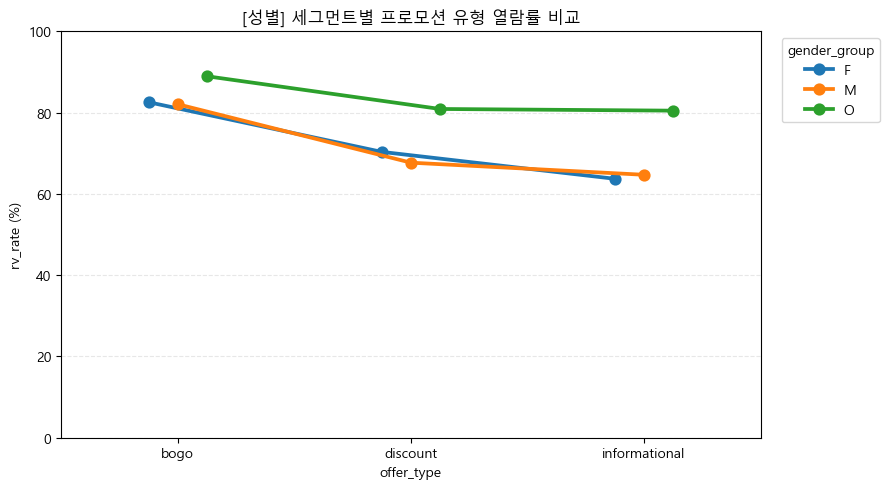

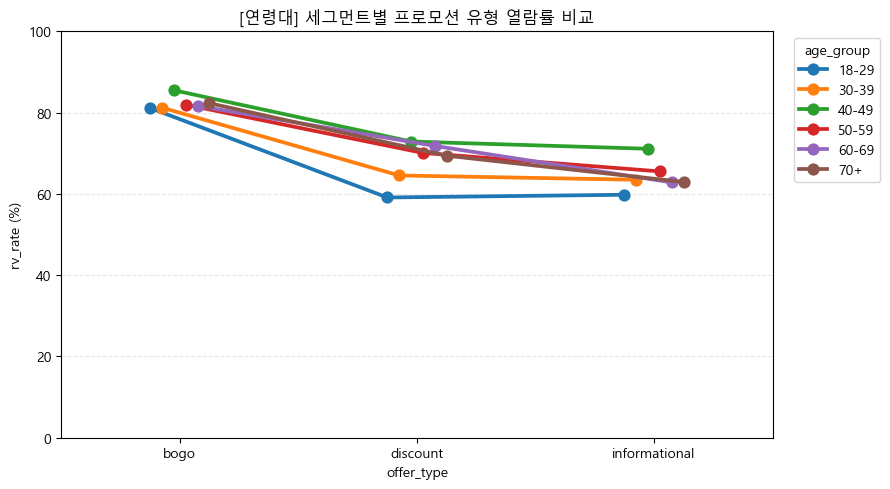

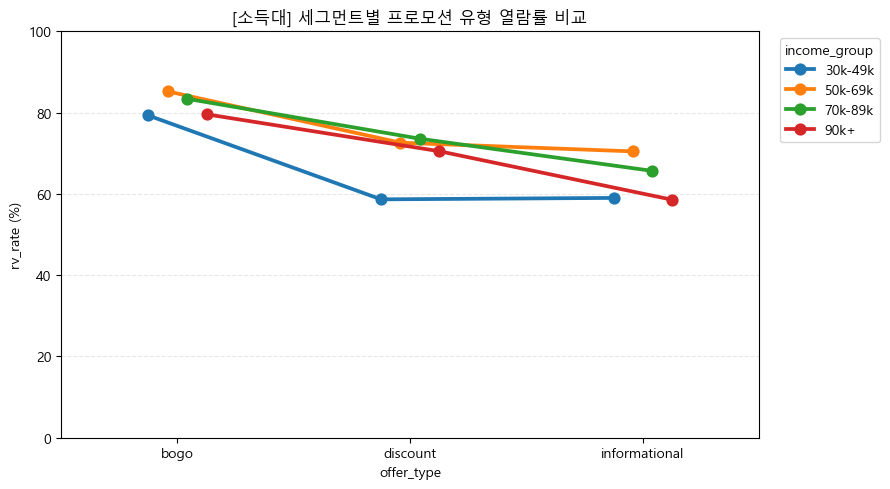

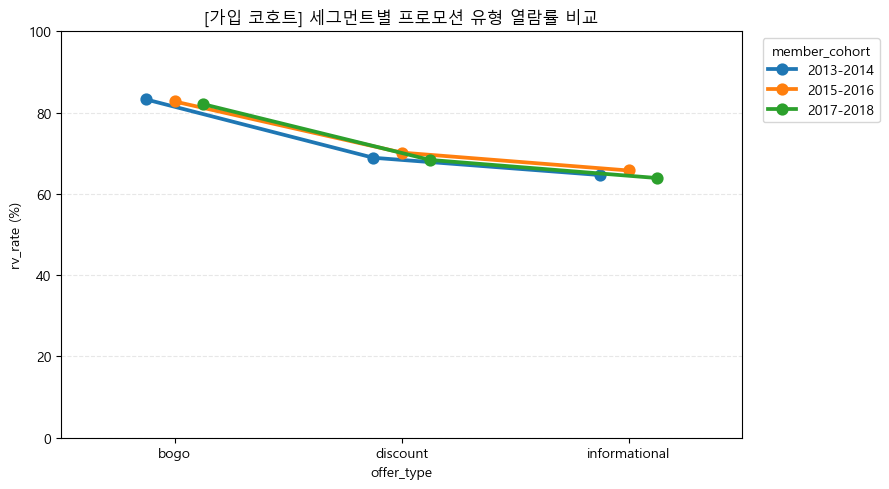

In [37]:
plot_segment_offer_point(gender_offer_rv_summary, 'gender_group', '성별', exclude_groups=['Missing'])
plot_segment_offer_point(age_offer_rv_summary, 'age_group', '연령대', exclude_groups=['Missing'])
plot_segment_offer_point(income_offer_rv_summary, 'income_group', '소득대', exclude_groups=['Missing'])
plot_segment_offer_point(cohort_offer_rv_summary, 'member_cohort', '가입 코호트', exclude_groups=['Missing'])

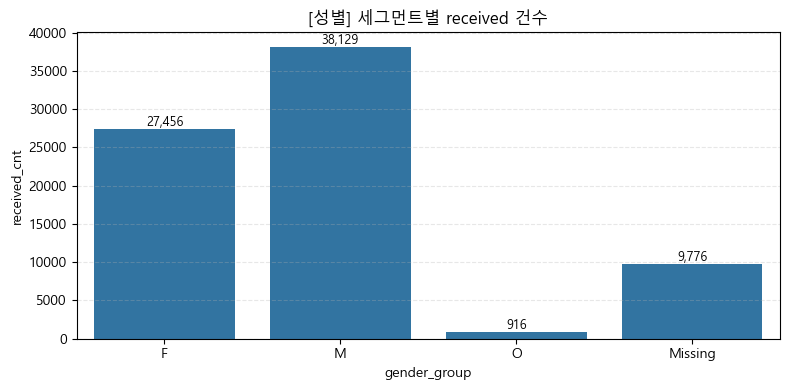

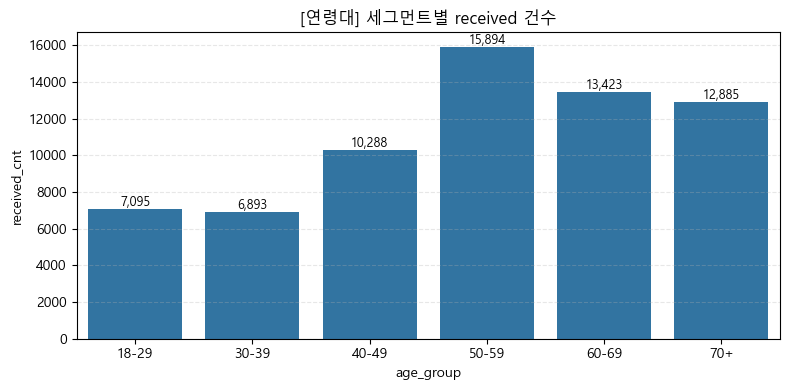

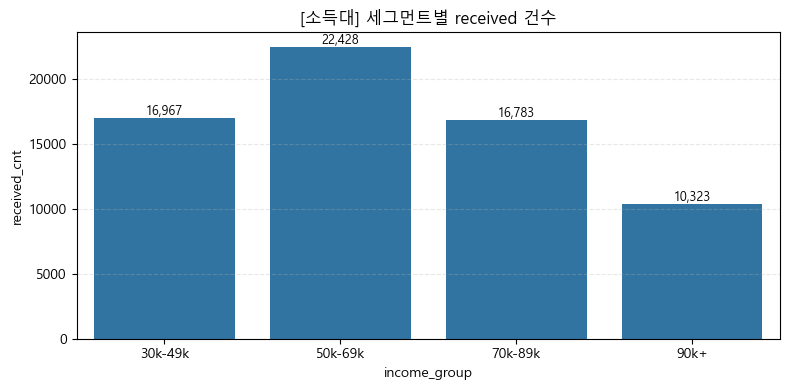

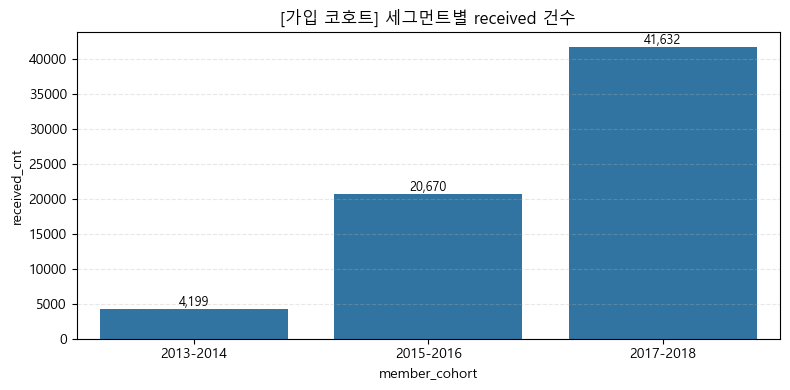

In [39]:
plot_segment_received_count(gender_offer_rv_summary, 'gender_group', '성별')
plot_segment_received_count(age_offer_rv_summary, 'age_group', '연령대', exclude_groups=['Missing'])
plot_segment_received_count(income_offer_rv_summary, 'income_group', '소득대', exclude_groups=['Missing'])
plot_segment_received_count(cohort_offer_rv_summary, 'member_cohort', '가입 코호트', exclude_groups=['Missing'])

# 1. 어떤 고객 세그먼트가 어떤 프로모션에 더 잘 반응하는가(열람)?
종합 보고서

- received → viewed : 열람률
    - 오퍼가 실제로 고객에게 읽혔는가

- received → completed : 전체 완료율
    - 오퍼를 받은 사람 중 최종적으로 조건 충족까지 간 비율
    
- received → viewed → completed : 정상 퍼널 완료율
    - received 이후 viewed를 거치고, 그 다음 completed까지 순서대로 간 비율

## 1. 성별 세그먼트 해석

성별 전체 열람률을 보면\
여성(F)은 73.9%, 남성(M)은 72.9%로 나타나\
주요 성별 집단 간 차이는 크지 않았다.

즉, 성별은 오퍼를 '보는 단계'에서는 큰 차이를 만들지 않는 변수로 해석할 수 있다.\
다만 기타(O)와 Missing 집단은 열람률이 상대적으로 높게 나타났지만,\
해당 집단은 규모와 데이터 해석 측면에서 주의가 필요하므로 보조적으로만 참고하는 것이 적절하다.

오퍼 유형별로 보면\
bogo는 여성 82.6%, 남성 82.1%로 거의 동일하게 가장 높은 열람률을 보였다.\
discount는 여성 70.4%, 남성 67.7%로 여성이 소폭 높았고,\
informational은 여성 63.7%, 남성 64.7%로 큰 차이 없이 비슷한 수준이었다.

결과적으로 성별 기준에서는\
특정 성별이 압도적으로 더 반응한다기보다,\
남녀 모두 bogo 유형에 가장 잘 반응하고\
discount와 informational은 그보다 낮은 열람률을 보이는 공통 패턴이 확인된다.

## 2. 연령대 세그먼트 해석

연령대 전체 열람률을 보면\
40–49세가 77.7%로 가장 높았고,\
50–59세 73.9%, 60–69세 74.0%, 70세 이상 73.2%로 뒤를 이었다.\
반면 18–29세는 68.1%로 가장 낮아\
젊은 층일수록 오퍼를 실제로 확인하는 비율이 낮은 편으로 나타났다.

오퍼 유형별로 보면\
bogo는 거의 모든 연령대에서 81~85% 수준으로 가장 높은 열람률을 보였다.\
특히 40–49세는 bogo 열람률이 85.5%로 가장 높았다

discount는 연령대별 차이가 더 뚜렷했다.\
18–29세는 59.1%로 가장 낮았고,\
40–49세는 72.9%, 60–69세는 71.8%로 상대적으로 높게 나타났다.

informational 역시\
18–29세 59.8%, 30–39세 63.5%, 40–49세 71.1%로\
연령대에 따라 열람률 차이가 존재했다.

결과적으로 연령대 기준에서는\
20대의 열람 반응이 가장 약하고,\
40대 이상에서 오퍼 확인 비율이 더 높게 나타났다.\
특히 bogo는 전 연령대에서 강한 열람 반응을 보이며,\
discount와 informational은 연령대에 따라 차이가 더 크게 나타난다.

## 3. 소득대 세그먼트 해석

소득대 전체 열람률을 보면\
50k–69k가 77.2%로 가장 높았고,\
70k–89k는 76.0%, 90k+는 71.8%,\
30k–49k는 67.0%로 가장 낮게 나타났다.

즉, 소득이 아주 높을수록 무조건 열람률이 높아진다기보다는\
중상위 소득 구간에서 오퍼 열람 반응이 가장 강하게 나타나는 구조로 볼 수 있다.

오퍼 유형별로 보면\
bogo는 50k–69k에서 85.3%, 70k–89k에서 83.4%로 높게 나타났고,\
30k–49k와 90k+는 각각 79.3%, 79.6% 수준이었다.

discount는\
30k–49k가 58.7%로 가장 낮았고,\
50k–69k는 72.6%, 70k–89k는 73.6%로 높게 나타났다.\
90k+도 70.5%로 낮지 않은 수준이지만,\
중간 소득대보다 아주 높지는 않았다

informational은 전체적으로 열람률이 더 낮았고,\
50k–69k에서 70.5%로 가장 높았으며\
90k+에서는 58.6%로 상대적으로 낮았다.

결과적으로 소득대 기준에서는\
저소득 구간의 열람 반응이 가장 약하고,\
50k–89k 구간에서 전반적으로 가장 안정적인 열람 반응이 나타났다.\
따라서 열람 단계 기준 타깃 반응층은\
중간~중상위 소득대라고 해석할 수 있다.

## 4. 가입 코호트 세그먼트 해석

가입 코호트 전체 열람률을 보면\
2015–2016 가입 고객이 74.3%로 가장 높았고,\
2013–2014는 73.8%, 2017–2018은 73.0%로 나타났다.

즉, 가입 시점에 따른 차이는 존재하지만\
성별이나 연령대에 비해 그 격차는 크지 않은 편이다.

오퍼 유형별로 보면\
bogo는 2013–2014 83.3%, 2015–2016 82.8%, 2017–2018 82.1%로\
모든 코호트에서 매우 비슷하게 높게 나타났다.

discount는\
2015–2016이 70.2%로 가장 높았고,\
2013–2014는 68.9%, 2017–2018은 68.4%였다.

informational 역시\
2015–2016이 65.8%로 가장 높았고,\
2013–2014는 64.7%, 2017–2018은 63.9%로 큰 차이는 아니지만\
기존 가입층이 조금 더 잘 확인하는 경향이 보였다.

결과적으로 가입 코호트 기준에서는\
2015–2016 가입 고객의 열람 반응이 가장 높지만,\
전체적으로는 코호트 차이보다\
오퍼 유형 자체의 차이가 더 크게 작용한다고 볼 수 있다.

## 종합 해석
전체적으로 고객 세그먼트별 열람률을 비교한 결과,\
오퍼를 '보는 단계'에서는 성별 차이는 크지 않았고,\
연령대와 소득대에서 상대적으로 더 뚜렷한 차이가 나타났다.\

연령대 기준으로는 18–29세의 열람률이 가장 낮았고,\
40대 이상에서 더 높은 열람 반응이 확인되었다.\
소득대 기준으로는 30k–49k가 가장 낮았으며,\
50k–89k 구간에서 전반적으로 높은 열람률이 나타났다.

프로모션 유형별로는 거의 모든 세그먼트에서\
bogo의 열람률이 가장 높았고,\
discount가 그 다음, informational이 가장 낮은 패턴이 반복되었다.


따라서 열람 단계의 프로모션 전략에서는\
모든 고객에게 동일한 오퍼를 일괄 적용하기보다,\
반응성이 높은 중간 연령·중간 소득층에는 다양한 오퍼를 운영하고,\
젊은층과 저소득층에는 상대적으로 주목도가 높은 bogo 중심 전략을 우선 검토하는 것이 적절하다.

# 2. 채널 조합에 따라 오퍼 반응률은 어떻게 달라지는가?
오퍼의 채널 조합에 따라 반응률 차이가 있는가?

- 채널 종류
    - web
    - email
    - mobile
    - social


- 사용 지표
    - `converted_rv` : 오퍼를 받은 뒤 실제로 열람했는가
    - `converted_rc` : 오퍼를 받은 뒤 완료했는가
    - `converted_rvc` : 오퍼를 받고, 열람 후, 완료까지 이어졌는가

## 1. 채널 조합 컬럼 생성

In [44]:
# ============================================================
# 1. 채널 조합 컬럼 생성
# ============================================================

channel_cols = ['web', 'email', 'mobile', 'social']

funnel_channel = funnel_seg.copy()

for col in channel_cols:
    funnel_channel[col] = funnel_channel[col].fillna(0).astype(int)

def make_channel_combo(row):
    channels = []
    
    if row['web'] == 1:
        channels.append('web')
    if row['email'] == 1:
        channels.append('email')
    if row['mobile'] == 1:
        channels.append('mobile')
    if row['social'] == 1:
        channels.append('social')
    
    return ' + '.join(channels) if channels else 'none'

funnel_channel['channel_combo'] = funnel_channel.apply(make_channel_combo, axis=1)

print("채널 조합 종류 수:", funnel_channel['channel_combo'].nunique())
display(
    funnel_channel[
        ['offer_id', 'offer_type', 'web', 'email', 'mobile', 'social', 'channel_combo']
    ]
    .drop_duplicates()
    .sort_values(['offer_type', 'channel_combo'])
)


채널 조합 종류 수: 4


,offer_id,offer_type,web,email,mobile,social,channel_combo
14,ae264e3637204a6fb9bb56bc8210ddfd,bogo,0,1,1,1,email + mobile + social
11,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,1,1,1,0,web + email + mobile
3,f19421c1d4aa40978ebb69ca19b0e20d,bogo,1,1,1,1,web + email + mobile + social
12,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,1,1,1,1,web + email + mobile + social
7,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,1,1,0,0,web + email
0,2906b810c7d4411798c6938adc9daaa5,discount,1,1,1,0,web + email + mobile
4,fafdcd668e3743c1bb461111dcafc2a4,discount,1,1,1,1,web + email + mobile + social
8,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,1,1,1,1,web + email + mobile + social
2,5a8bc65990b245e5a138643cd4eb9837,informational,0,1,1,1,email + mobile + social
1,3f207df678b143eea3cee63160fa8bed,informational,1,1,1,0,web + email + mobile


## 2. 채널 조합별 기본 분포 확인

In [45]:
# ============================================================
# 2. 채널 조합별 기본 분포 확인
# ============================================================

channel_dist = (
    funnel_channel['channel_combo']
    .value_counts(dropna=False)
    .rename_axis('channel_combo')
    .reset_index(name='received_cnt')
)

print("=" * 70)
print("채널 조합별 received 건수")
print("=" * 70)
display(channel_dist)

채널 조합별 received 건수


,channel_combo,received_cnt
0,web + email + mobile + social,30407
1,web + email + mobile,22926
2,email + mobile + social,15276
3,web + email,7668


## 3. 채널 조합별 전체 반응률 요약표

In [46]:
# ============================================================
# 3. 채널 조합별 전체 반응률 요약표
# ============================================================
channel_summary = (
    funnel_channel
    .groupby('channel_combo', dropna=False)
    .agg(
        received_cnt=('customer_id', 'size'),
        viewed_cnt=('converted_rv', 'sum'),
        completed_cnt=('converted_rc', 'sum'),
        strict_completed_cnt=('converted_rvc', 'sum')
    )
    .reset_index()
)

channel_summary['rv_rate'] = channel_summary['viewed_cnt'] / channel_summary['received_cnt'] * 100
channel_summary['rc_rate'] = channel_summary['completed_cnt'] / channel_summary['received_cnt'] * 100
channel_summary['rvc_rate'] = channel_summary['strict_completed_cnt'] / channel_summary['received_cnt'] * 100

channel_summary = channel_summary.sort_values('received_cnt', ascending=False).reset_index(drop=True)

print("=" * 70)
print("채널 조합별 전체 반응률 요약표")
print("=" * 70)
display(channel_summary)

채널 조합별 전체 반응률 요약표


,channel_combo,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,web + email + mobile + social,30407,29100,17922,15299,95.701648,58.940376,50.314072
1,web + email + mobile,22926,11987,8261,4252,52.285615,36.033325,18.546628
2,email + mobile + social,15276,12828,3635,2613,83.974863,23.795496,17.105263
3,web + email,7668,2652,3334,1332,34.585290,43.479395,17.370892


## 4. 채널 조합 × offer_type 요약표

In [47]:
# ============================================================
# 4. 채널 조합 × offer_type 반응률 요약표
# ============================================================
channel_offer_summary = (
    funnel_channel
    .groupby(['channel_combo', 'offer_type'], dropna=False)
    .agg(
        received_cnt=('customer_id', 'size'),
        viewed_cnt=('converted_rv', 'sum'),
        completed_cnt=('converted_rc', 'sum'),
        strict_completed_cnt=('converted_rvc', 'sum')
    )
    .reset_index()
)

channel_offer_summary['rv_rate'] = channel_offer_summary['viewed_cnt'] / channel_offer_summary['received_cnt'] * 100
channel_offer_summary['rc_rate'] = channel_offer_summary['completed_cnt'] / channel_offer_summary['received_cnt'] * 100
channel_offer_summary['rvc_rate'] = channel_offer_summary['strict_completed_cnt'] / channel_offer_summary['received_cnt'] * 100

channel_offer_summary = channel_offer_summary.sort_values(
    ['channel_combo', 'offer_type']
).reset_index(drop=True)

print("=" * 70)
print("채널 조합 × offer_type 반응률 요약표")
print("=" * 70)
display(channel_offer_summary)

채널 조합 × offer_type 반응률 요약표


,channel_combo,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,email + mobile + social,bogo,7658,6679,3635,2613,87.215983,47.466701,34.121180
1,email + mobile + social,informational,7618,6149,0,0,80.716724,0.000000,0.000000
2,web + email,discount,7668,2652,3334,1332,34.585290,43.479395,17.370892
3,web + email + mobile,bogo,7677,4128,4303,2124,53.771004,56.050541,27.667057
4,web + email + mobile,discount,7632,4061,3958,2128,53.210168,51.860587,27.882600
5,web + email + mobile,informational,7617,3798,0,0,49.862150,0.000000,0.000000
6,web + email + mobile + social,bogo,15164,14443,7563,6287,95.245318,49.874703,41.460037
7,web + email + mobile + social,discount,15243,14657,10359,9012,96.155612,67.959063,59.122220


## 5. 시각화

In [48]:
channel_order = (
    channel_summary
    .sort_values('received_cnt', ascending=False)['channel_combo']
    .tolist()
)


### 그래프 함수

In [49]:
def plot_channel_received_count(summary_df):
    df_a = summary_df.copy()
    df_a['channel_combo'] = pd.Categorical(
        df_a['channel_combo'],
        categories=channel_order,
        ordered=True
    )
    df_a = df_a.sort_values('channel_combo')

    plt.figure(figsize=(9, 4))
    sns.barplot(data=df_a, x='channel_combo', y='received_cnt')

    plt.title('채널 조합별 received 건수')
    plt.xlabel('channel_combo')
    plt.ylabel('received_cnt')
    plt.xticks(rotation=25)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    for i, v in enumerate(df_a['received_cnt']):
        plt.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

In [50]:
def plot_channel_metric_compare(summary_df):
    df_a = summary_df.copy()

    metric_map = {
        'rv_rate': '열람률',
        'rc_rate': '완료율',
        'rvc_rate': '정상 퍼널 완료율'
    }

    plot_df = df_a.melt(
        id_vars=['channel_combo', 'received_cnt'],
        value_vars=['rv_rate', 'rc_rate', 'rvc_rate'],
        var_name='metric',
        value_name='rate'
    )

    plot_df['metric'] = plot_df['metric'].map(metric_map)
    plot_df['channel_combo'] = pd.Categorical(
        plot_df['channel_combo'],
        categories=channel_order,
        ordered=True
    )
    plot_df = plot_df.sort_values(['channel_combo', 'metric'])

    plt.figure(figsize=(10, 5))
    sns.pointplot(
        data=plot_df,
        x='channel_combo',
        y='rate',
        hue='metric',
        dodge=0.35,
        markers='o',
        linestyles='-'
    )

    plt.title('채널 조합별 전체 반응률 비교')
    plt.xlabel('channel_combo')
    plt.ylabel('rate (%)')
    plt.xticks(rotation=25)
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(title='')
    plt.tight_layout()
    plt.show()

In [51]:
offer_order = ['bogo', 'discount', 'informational']

def plot_channel_offer_rv(summary_df):
    df_a = summary_df.copy()

    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=offer_order,
        ordered=True
    )
    df_a['channel_combo'] = pd.Categorical(
        df_a['channel_combo'],
        categories=channel_order,
        ordered=True
    )
    df_a = df_a.sort_values(['offer_type', 'channel_combo'])

    plt.figure(figsize=(10, 5))
    sns.pointplot(
        data=df_a,
        x='offer_type',
        y='rv_rate',
        hue='channel_combo',
        dodge=0.3,
        markers='o',
        linestyles='-'
    )

    plt.title('채널 조합 × 프로모션 유형 열람률 비교')
    plt.xlabel('offer_type')
    plt.ylabel('rv_rate (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(title='channel_combo', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [52]:
def plot_channel_offer_completion(summary_df, rate_col='rc_rate'):
    df_a = summary_df.copy()

    df_a = df_a[df_a['offer_type'].isin(['bogo', 'discount'])].copy()

    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=['bogo', 'discount'],
        ordered=True
    )
    df_a['channel_combo'] = pd.Categorical(
        df_a['channel_combo'],
        categories=channel_order,
        ordered=True
    )
    df_a = df_a.sort_values(['offer_type', 'channel_combo'])

    rate_name_map = {
        'rc_rate': '완료율',
        'rvc_rate': '정상 퍼널 완료율'
    }
    rate_name = rate_name_map.get(rate_col, rate_col)

    plt.figure(figsize=(10, 5))
    sns.pointplot(
        data=df_a,
        x='offer_type',
        y=rate_col,
        hue='channel_combo',
        dodge=0.3,
        markers='o',
        linestyles='-'
    )

    plt.title(f'채널 조합 × 프로모션 유형 {rate_name} 비교')
    plt.xlabel('offer_type')
    plt.ylabel(f'{rate_name} (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(title='channel_combo', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

### 그래프 출력

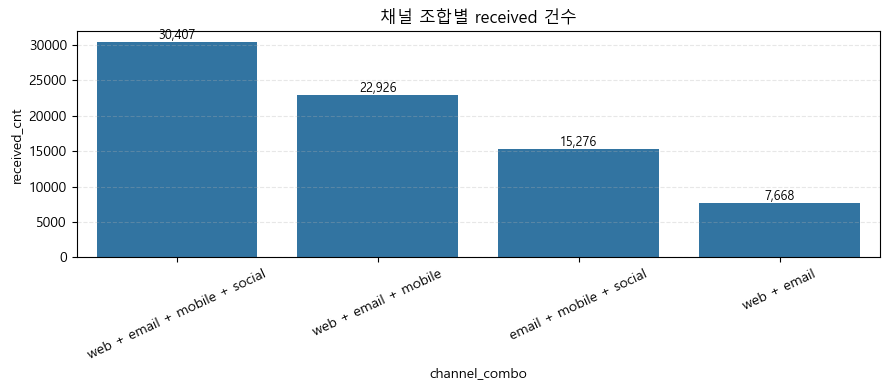

In [53]:
plot_channel_received_count(channel_summary)

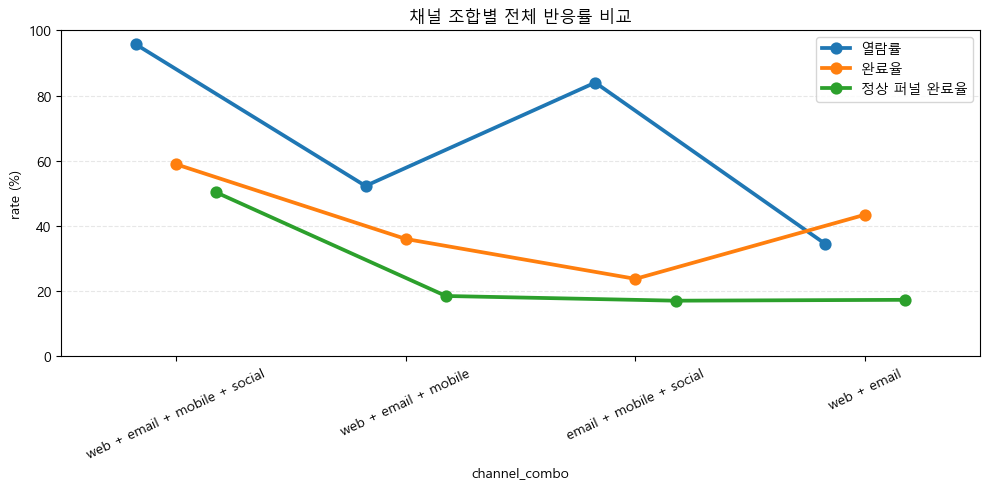

In [54]:
plot_channel_metric_compare(channel_summary)

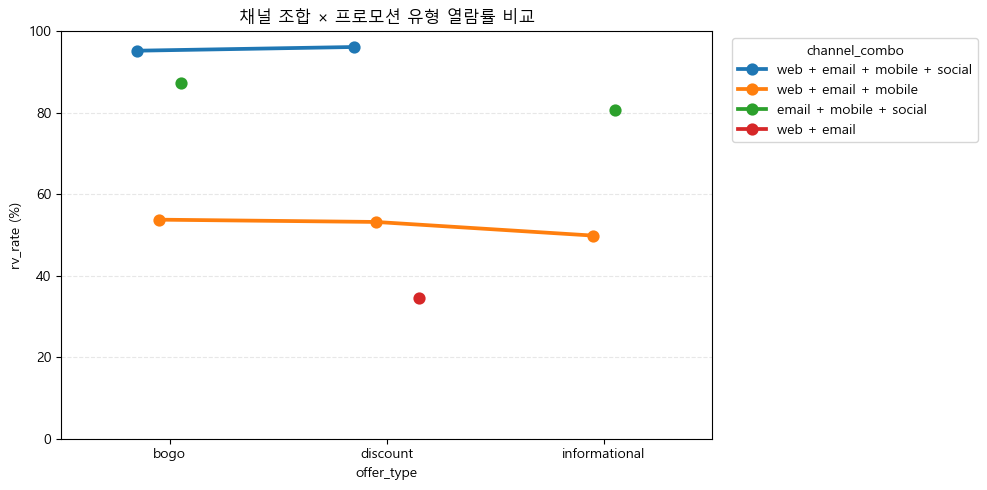

In [55]:
plot_channel_offer_rv(channel_offer_summary)

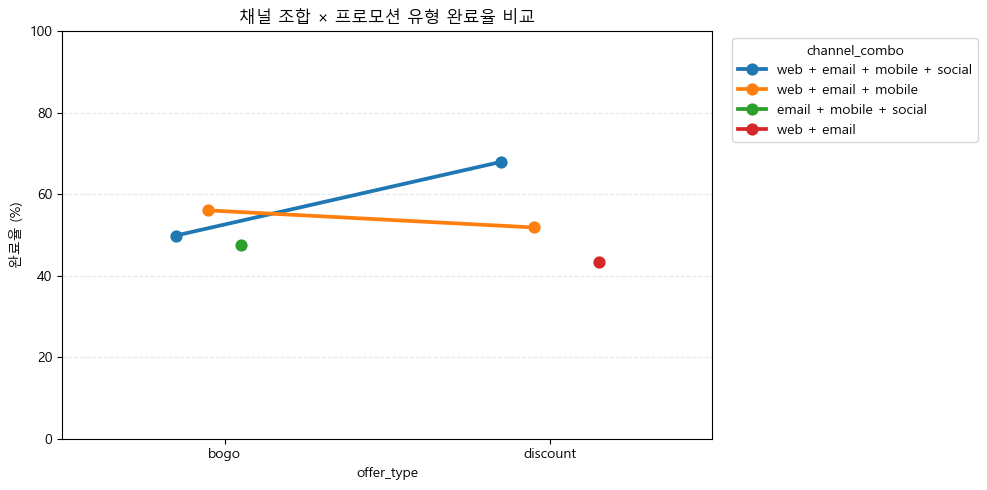

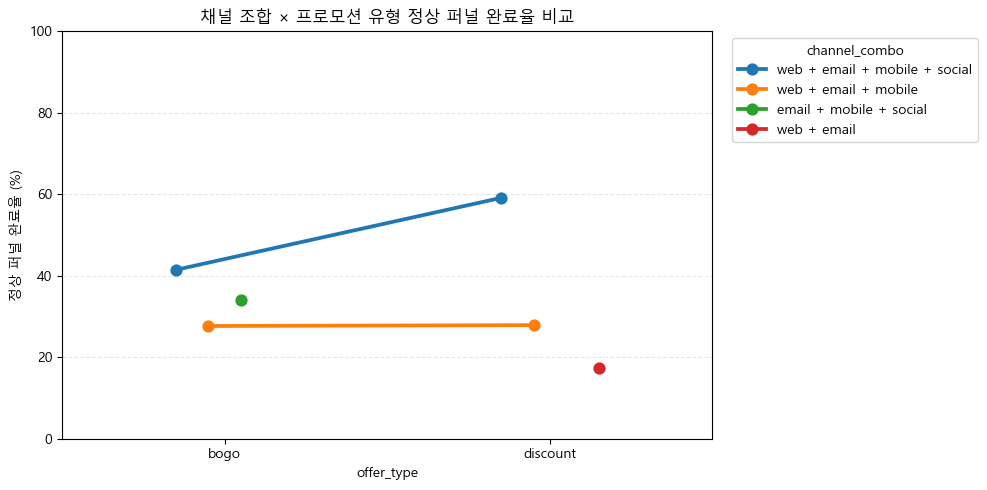

In [56]:
plot_channel_offer_completion(channel_offer_summary, 'rc_rate')
plot_channel_offer_completion(channel_offer_summary, 'rvc_rate')

# 2. 채널 조합에 따라 오퍼 반응률은 어떻게 달라지는가?
종합 보고서

## 1. 전체 수치 요약
- web + email + mobile + social
    - 열람률 95.7%
    - 완료율 58.9%
    - 정상 퍼널 완료율 50.3%
- email + mobile + social
    - 열람률 84.0%
    - 완료율 23.8%
    - 정상 퍼널 완료율 17.1%
- web + email + mobile
    - 열람률 52.3%
    - 완료율 36.0%
    - 정상 퍼널 완료율 18.5%
- web + email
    - 열람률 34.6%
    - 완료율 43.5%
    -정상 퍼널 완료율 17.4%

## 2. 채널 조합별 해석
전체 채널 조합 중 가장 높은 반응을 보인 것은 web + email + mobile + social 조합이었다.\
이 조합은 열람률이 95.7%, 완료율이 58.9%, 정상 퍼널 완료율이 50.3%로 가장 높게 나타났다.
즉, 오퍼를 받은 대부분의 고객이 실제로 오퍼를 확인했고, 그중 상당수가 열람 이후 완료까지 이어졌다는 뜻이다.

반면 email + mobile + social 조합은 열람률이 84.0%로 높은 편이었지만, 완료율은 23.8%, 정상 퍼널 완료율은 17.1%로 낮게 나타났다.\
즉, 오퍼 자체는 비교적 잘 확인되었지만, 그 이후 실제 완료 행동으로는 잘 이어지지 못했다는 뜻이다.

web + email + mobile 조합은 열람률 52.3%, 완료율 36.0%, 정상 퍼널 완료율 18.5%로 중간 수준의 반응을 보였다.

web + email 조합은 열람률이 34.6%로 가장 낮았는데, 완료율은 43.5%로 열람률보다 높게 나타났다.

- 주의 포인트
    - web + email 조합은 discount 오퍼만 포함한다.
    - web + email + mobile + social 조합은 bogo와 discount 중심이다.
    - email + mobile + social 조합은 bogo와 informational이 섞여 있다.


## 2. 종합해석
전체 반응률 기준에서는 web + email + mobile + social 조합이 가장 높은 성과를 보였다.\
다만 채널 조합이 오퍼별로 고정된 설계 속성과 함께 운영되고 있어, 이를 채널 자체의 순수 효과로\
단정하기보다는 현재 운영된 오퍼-채널 조합 중 가장 강한 반응 패턴을 보인 구성으로 해석하는 것이 적절하다.

email + mobile + social은 열람은 잘 되었지만 완료까지는 잘 이어지지 않았고,\
web + email, web + email + mobile은 퍼널 흐름이 다소 약하게 나타났다.

결론적으로,\
다채널 조합이 고객 주목도 확보에는 유리하다는 점을 참고하되,\
실제 완료 성과를 높이기 위해서는 채널 조합을 오퍼 유형과 함께 설계하는 것이 중요하다고 해석할 수 있다.

# 3. 어떤 고객군이 오퍼를 본 뒤 완료까지 더 잘 이어지는가?
오퍼를 실제로 열람한 고객들 중, 어떤 고객군이 completed까지 더 잘 이어지는가?

received 기준 반응 분석과 다르게, `viewed`를 기준으로 completed 전환을 본다.

- 사용 지표
    - `converted_vc` : viewed → completed 전환 여부
    - `vc_rate` : viewed 대비 completed 비율
    - `vc_time_diff` : viewed 후 completed까지 걸린 시간

## 1. viewed 기준 분석용 데이터 준비

In [57]:
# ============================================================
# 1. viewed 기준 분석용 데이터 준비
# ============================================================

funnel_vc = funnel_seg.copy()

# viewed된 건만 남김
funnel_vc = funnel_vc[funnel_vc['converted_rv'] == 1].copy()

# completed 해석이 가능한 유형만 남김
funnel_vc_main = funnel_vc[funnel_vc['offer_type'].isin(['bogo', 'discount'])].copy()

print("viewed 기준 전체 행 수:", len(funnel_vc))
print("viewed 기준 고객 수:", funnel_vc['customer_id'].nunique())
print()

print("bogo / discount 기준 viewed 행 수:", len(funnel_vc_main))
print("bogo / discount 기준 viewed 고객 수:", funnel_vc_main['customer_id'].nunique())
display(funnel_vc_main.head())

viewed 기준 전체 행 수: 56567
viewed 기준 고객 수: 16793

bogo / discount 기준 viewed 행 수: 46620
bogo / discount 기준 viewed 고객 수: 16489


,customer_id,offer_id,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,time_received,offer_end_time,rv_time_diff,rc_time_diff,vc_time_diff,converted_rv,converted_rc,converted_vc,converted_rvc,gender,age,income,became_member_on,gender_group,age_clean,age_group,income_group,member_year,member_cohort
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,408,528.0,48.0,6.0,NaN,1,1,0,0,M,33.0,72000.0,2017-04-21,M,33.0,30-39,70k-89k,2017,2017-2018
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,1.0,1.0,1.0,1.0,504,744.0,36.0,24.0,NaN,1,1,0,0,M,33.0,72000.0,2017-04-21,M,33.0,30-39,70k-89k,2017,2017-2018
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,168,288.0,48.0,NaN,NaN,1,0,0,0,NaN,NaN,NaN,<NA>,Missing,NaN,Missing,Missing,<NA>,Missing
6,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,576,696.0,54.0,NaN,NaN,1,0,0,0,NaN,NaN,NaN,<NA>,Missing,NaN,Missing,Missing,<NA>,Missing
7,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,5.0,20.0,10.0,1.0,1.0,0.0,0.0,408,648.0,24.0,168.0,144.0,1,1,1,1,O,40.0,57000.0,2018-01-09,O,40.0,40-49,50k-69k,2018,2017-2018


## 2. viewed 기준 offer_type 분포

In [58]:
# ============================================================
# 2. viewed 기준 offer_type 분포
# ============================================================
view_offer_dist = (
    funnel_vc_main['offer_type']
    .value_counts(dropna=False)
    .rename_axis('offer_type')
    .reset_index(name='viewed_cnt')
)

print("=" * 70)
print("viewed 기준 offer_type 분포")
print("=" * 70)
display(view_offer_dist)

viewed 기준 offer_type 분포


,offer_type,viewed_cnt
0,bogo,25250
1,discount,21370


## 3. 고객군별 VC 요약 함수

In [59]:
# ============================================================
# 3. 고객군별 viewed -> completed 요약 함수
# ============================================================
def make_segment_vc_summary(df, segment_col):
    summary = (
        df.groupby(segment_col, dropna=False)
        .agg(
            viewed_cnt=('customer_id', 'size'),
            completed_after_view_cnt=('converted_vc', 'sum'),
            avg_vc_time=('vc_time_diff', 'mean')
        )
        .reset_index()
    )
    
    summary['vc_rate'] = summary['completed_after_view_cnt'] / summary['viewed_cnt'] * 100
    summary = summary.sort_values('viewed_cnt', ascending=False).reset_index(drop=True)
    
    return summary

In [60]:
gender_vc_summary = make_segment_vc_summary(funnel_vc_main, 'gender_group')
age_vc_summary = make_segment_vc_summary(funnel_vc_main, 'age_group')
income_vc_summary = make_segment_vc_summary(funnel_vc_main, 'income_group')
cohort_vc_summary = make_segment_vc_summary(funnel_vc_main, 'member_cohort')

print("=" * 70)
print("gender_group 기준 viewed -> completed 요약")
print("=" * 70)
display(gender_vc_summary)

print("=" * 70)
print("age_group 기준 viewed -> completed 요약")
print("=" * 70)
display(age_vc_summary)

print("=" * 70)
print("income_group 기준 viewed -> completed 요약")
print("=" * 70)
display(income_vc_summary)

print("=" * 70)
print("member_cohort 기준 viewed -> completed 요약")
print("=" * 70)
display(cohort_vc_summary)

gender_group 기준 viewed -> completed 요약


,gender_group,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,M,22881,11655,47.171686,50.937459
1,F,16765,10507,40.514133,62.672234
2,Missing,6362,944,81.165254,14.838101
3,O,612,390,41.646154,63.725490


age_group 기준 viewed -> completed 요약


,age_group,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,50-59,9649,5682,42.248152,58.886931
1,60-69,8270,4761,44.514178,57.569528
2,70+,7772,4570,42.771991,58.800823
3,40-49,6537,3627,44.689826,55.484167
4,Missing,6373,952,80.722689,14.938020
5,30-39,4013,2119,45.227938,52.803389
6,18-29,4006,1785,48.235294,44.558163


income_group 기준 viewed -> completed 요약


,income_group,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,50k-69k,14087,7720,45.780311,54.802300
1,70k-89k,10593,6641,41.379310,62.692344
2,30k-49k,9391,4107,50.100804,43.733362
3,Missing,6362,944,81.165254,14.838101
4,90k+,6187,4084,38.619491,66.009374


member_cohort 기준 viewed -> completed 요약


,member_cohort,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,2017-2018,25049,11916,48.594159,47.570761
1,2015-2016,12659,9209,36.243675,72.746662
2,Missing,6362,944,81.165254,14.838101
3,2013-2014,2550,1427,55.286615,55.960784


## 4. 고객군 × offer_type VC 요약 함수

In [61]:
# ============================================================
# 4. 고객군 × offer_type viewed -> completed 요약 함수
# ============================================================
def make_segment_offer_vc_summary(df, segment_col):
    summary = (
        df.groupby([segment_col, 'offer_type'], dropna=False)
        .agg(
            viewed_cnt=('customer_id', 'size'),
            completed_after_view_cnt=('converted_vc', 'sum'),
            avg_vc_time=('vc_time_diff', 'mean')
        )
        .reset_index()
    )
    
    summary['vc_rate'] = summary['completed_after_view_cnt'] / summary['viewed_cnt'] * 100
    summary = summary.sort_values([segment_col, 'offer_type']).reset_index(drop=True)
    
    return summary

In [62]:
gender_offer_vc_summary = make_segment_offer_vc_summary(funnel_vc_main, 'gender_group')
age_offer_vc_summary = make_segment_offer_vc_summary(funnel_vc_main, 'age_group')
income_offer_vc_summary = make_segment_offer_vc_summary(funnel_vc_main, 'income_group')
cohort_offer_vc_summary = make_segment_offer_vc_summary(funnel_vc_main, 'member_cohort')

print("=" * 70)
print("gender_group × offer_type viewed -> completed 요약")
print("=" * 70)
display(gender_offer_vc_summary)

print("=" * 70)
print("age_group × offer_type viewed -> completed 요약")
print("=" * 70)
display(age_offer_vc_summary)

print("=" * 70)
print("income_group × offer_type viewed -> completed 요약")
print("=" * 70)
display(income_offer_vc_summary)

print("=" * 70)
print("member_cohort × offer_type viewed -> completed 요약")
print("=" * 70)
display(cohort_offer_vc_summary)

gender_group × offer_type viewed -> completed 요약


,gender_group,offer_type,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,F,bogo,9065,5254,34.829463,57.959184
1,F,discount,7700,5253,46.199886,68.220779
2,M,bogo,12485,5281,36.985041,42.298759
3,M,discount,10396,6374,55.611547,61.312043
4,Missing,bogo,3385,297,49.979798,8.774003
5,Missing,discount,2977,647,95.480680,21.733289
6,O,bogo,315,192,36.843750,60.952381
7,O,discount,297,198,46.303030,66.666667


age_group × offer_type viewed -> completed 요약


,age_group,offer_type,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,18-29,bogo,2298,790,33.660759,34.377720
1,18-29,discount,1708,995,59.807035,58.255269
2,30-39,bogo,2202,960,35.100000,43.596730
3,30-39,discount,1811,1159,53.616911,63.997791
4,40-49,bogo,3579,1738,36.514384,48.561051
5,40-49,discount,2958,1889,52.211752,63.860717
6,50-59,bogo,5183,2743,34.497266,52.923018
7,50-59,discount,4466,2939,49.482137,65.808330
8,60-69,bogo,4369,2237,37.654895,51.201648
9,60-69,discount,3901,2524,50.593502,64.701359


income_group × offer_type viewed -> completed 요약


,income_group,offer_type,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,30k-49k,bogo,5379,1764,38.319728,32.794200
1,30k-49k,discount,4012,2343,58.970551,58.399801
2,50k-69k,bogo,7576,3610,36.034903,47.650475
3,50k-69k,discount,6511,4110,54.340146,63.123944
4,70k-89k,bogo,5598,3226,35.207688,57.627724
5,70k-89k,discount,4995,3415,47.209370,68.368368
6,90k+,bogo,3312,2127,34.849083,64.221014
7,90k+,discount,2875,1957,42.717425,68.069565
8,Missing,bogo,3385,297,49.979798,8.774003
9,Missing,discount,2977,647,95.480680,21.733289


member_cohort × offer_type viewed -> completed 요약


,member_cohort,offer_type,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,2013-2014,bogo,1388,525,44.491429,37.824207
1,2013-2014,discount,1162,902,61.569845,77.624785
2,2015-2016,bogo,6837,4489,30.824683,65.657452
3,2015-2016,discount,5822,4720,41.397458,81.071797
4,2017-2018,bogo,13640,5713,39.148608,41.884164
5,2017-2018,discount,11409,6203,57.293568,54.369358
6,Missing,bogo,3385,297,49.979798,8.774003
7,Missing,discount,2977,647,95.480680,21.733289


## 5. 시각화

In [ ]:
# 세그먼트 순서 설정
segment_order_map = {
    'gender_group': ['F', 'M', 'O', 'Missing'],
    'age_group': ['18-29', '30-39', '40-49', '50-59', '60-69', '70+', 'Missing'],
    'income_group': ['30k-49k', '50k-69k', '70k-89k', '90k+', 'Missing'],
    'member_cohort': ['2013-2014', '2015-2016', '2017-2018', 'Missing']
}

offer_order = ['bogo', 'discount']

### 그래프 함수

In [65]:
def plot_segment_offer_vc_point(summary_df, segment_col, group_title, exclude_groups=None):
    df_a = summary_df.copy()

    if exclude_groups is not None:
        df_a = df_a[~df_a[segment_col].isin(exclude_groups)].copy()

    if segment_col in segment_order_map:
        order_list = [x for x in segment_order_map[segment_col] if x in df_a[segment_col].unique()]
        df_a[segment_col] = pd.Categorical(
            df_a[segment_col],
            categories=order_list,
            ordered=True
        )

    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=offer_order,
        ordered=True
    )

    df_a = df_a.sort_values([segment_col, 'offer_type'])

    plt.figure(figsize=(9, 5))
    sns.pointplot(
        data=df_a,
        x='offer_type',
        y='vc_rate',
        hue=segment_col,
        order=offer_order,
        dodge=0.25,
        markers='o',
        linestyles='-'
    )

    plt.title(f'[{group_title}] 고객군 × 프로모션 유형 viewed → completed 전환률')
    plt.xlabel('offer_type')
    plt.ylabel('vc_rate (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(title=segment_col, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [66]:
def plot_segment_vc_bar(summary_df, segment_col, group_title, exclude_groups=None):
    df_a = summary_df.copy()

    if exclude_groups is not None:
        df_a = df_a[~df_a[segment_col].isin(exclude_groups)].copy()

    if segment_col in segment_order_map:
        order_list = [x for x in segment_order_map[segment_col] if x in df_a[segment_col].unique()]
        df_a[segment_col] = pd.Categorical(
            df_a[segment_col],
            categories=order_list,
            ordered=True
        )
        df_a = df_a.sort_values(segment_col)

    plt.figure(figsize=(9, 4.5))
    sns.barplot(data=df_a, x=segment_col, y='vc_rate')

    plt.title(f'[{group_title}] 고객군별 viewed → completed 전환률')
    plt.xlabel(segment_col)
    plt.ylabel('vc_rate (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    for i, v in enumerate(df_a['vc_rate']):
        plt.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

In [67]:
def plot_segment_viewed_count(summary_df, segment_col, group_title, exclude_groups=None):
    df_a = summary_df.copy()

    if exclude_groups is not None:
        df_a = df_a[~df_a[segment_col].isin(exclude_groups)].copy()

    if segment_col in segment_order_map:
        order_list = [x for x in segment_order_map[segment_col] if x in df_a[segment_col].unique()]
        df_a[segment_col] = pd.Categorical(
            df_a[segment_col],
            categories=order_list,
            ordered=True
        )
        df_a = df_a.sort_values(segment_col)

    plt.figure(figsize=(9, 4.5))
    sns.barplot(data=df_a, x=segment_col, y='viewed_cnt')

    plt.title(f'[{group_title}] 고객군별 viewed 건수')
    plt.xlabel(segment_col)
    plt.ylabel('viewed_cnt')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    for i, v in enumerate(df_a['viewed_cnt']):
        plt.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

### 시각화

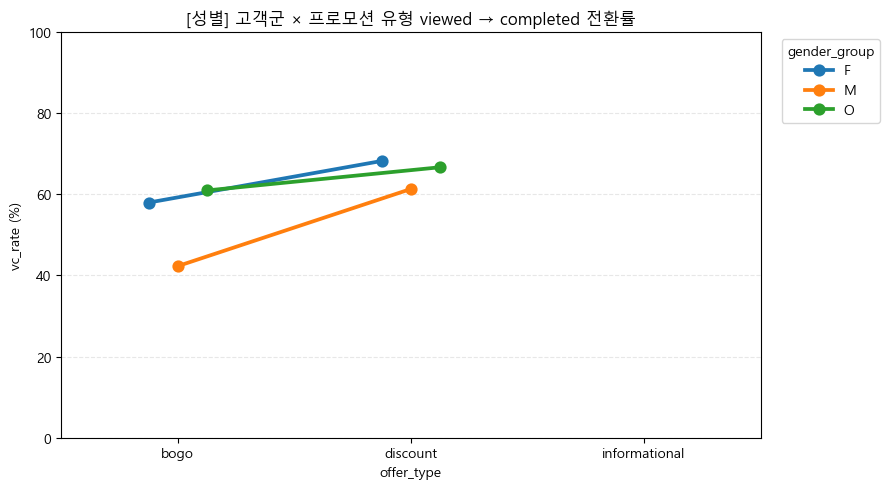

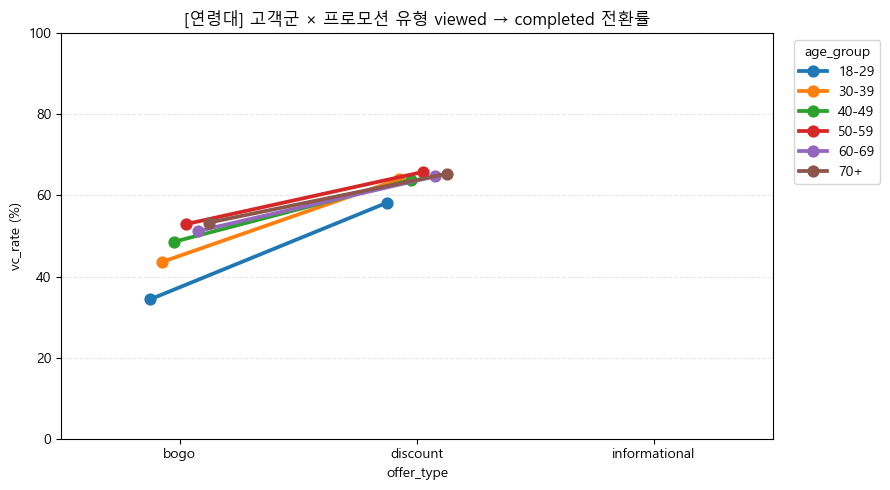

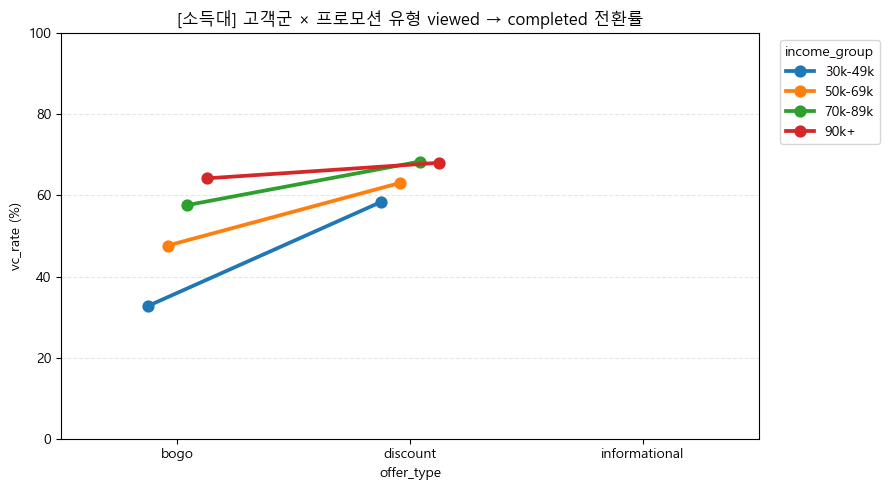

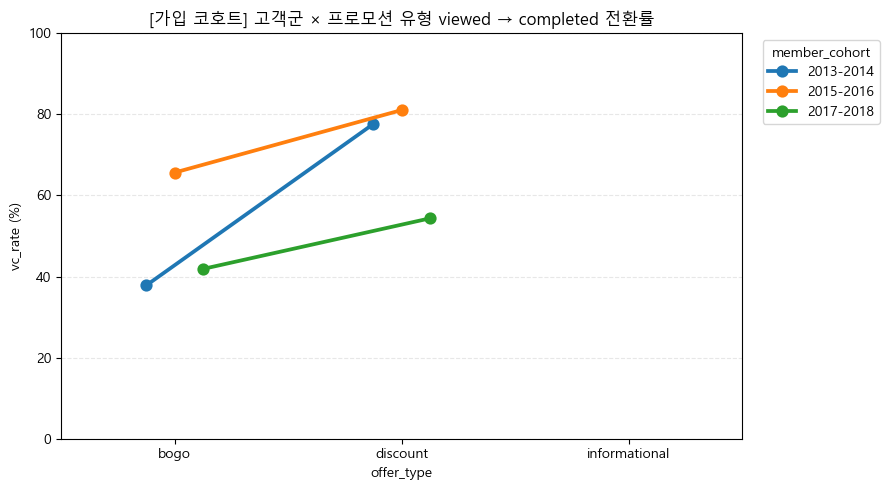

In [68]:
plot_segment_offer_vc_point(gender_offer_vc_summary, 'gender_group', '성별', exclude_groups=['Missing'])
plot_segment_offer_vc_point(age_offer_vc_summary, 'age_group', '연령대', exclude_groups=['Missing'])
plot_segment_offer_vc_point(income_offer_vc_summary, 'income_group', '소득대', exclude_groups=['Missing'])
plot_segment_offer_vc_point(cohort_offer_vc_summary, 'member_cohort', '가입 코호트', exclude_groups=['Missing'])

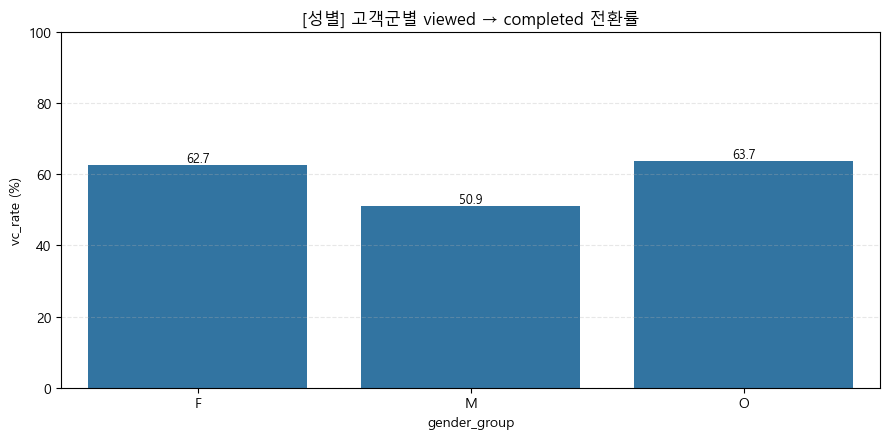

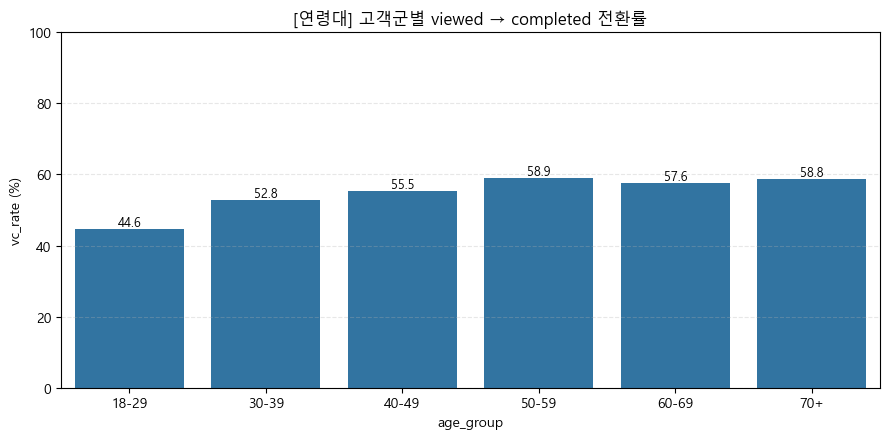

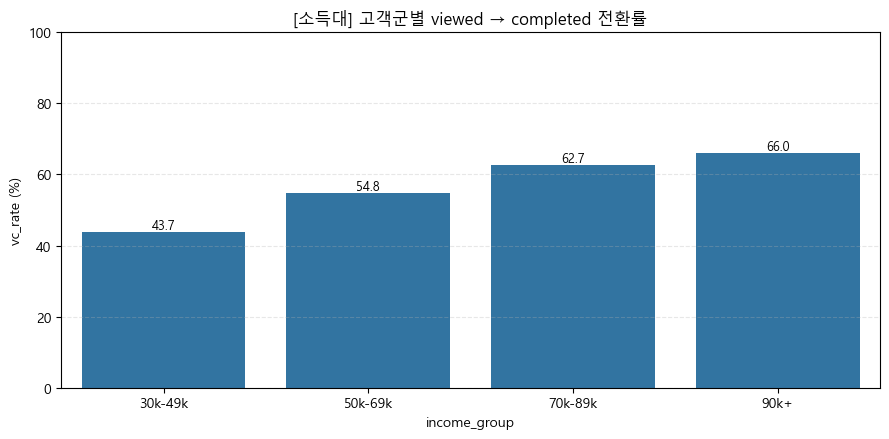

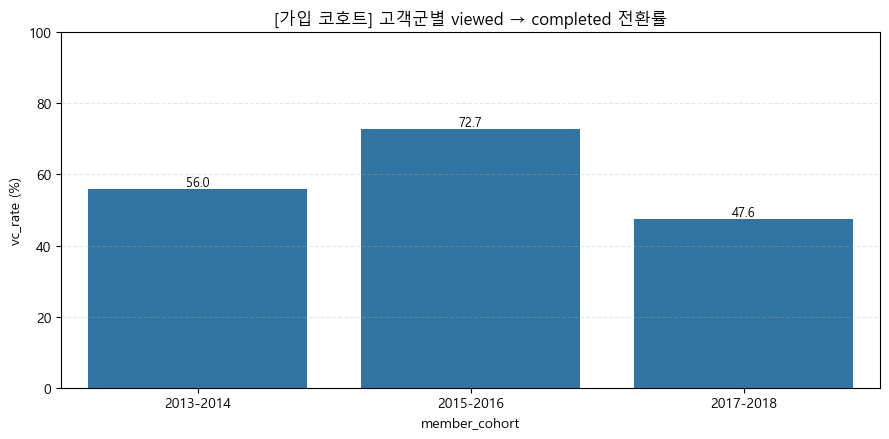

In [69]:
plot_segment_vc_bar(gender_vc_summary, 'gender_group', '성별', exclude_groups=['Missing'])
plot_segment_vc_bar(age_vc_summary, 'age_group', '연령대', exclude_groups=['Missing'])
plot_segment_vc_bar(income_vc_summary, 'income_group', '소득대', exclude_groups=['Missing'])
plot_segment_vc_bar(cohort_vc_summary, 'member_cohort', '가입 코호트', exclude_groups=['Missing'])

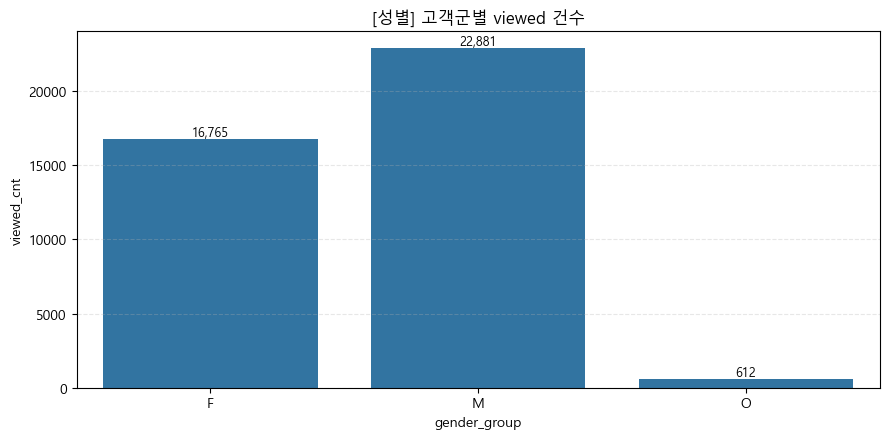

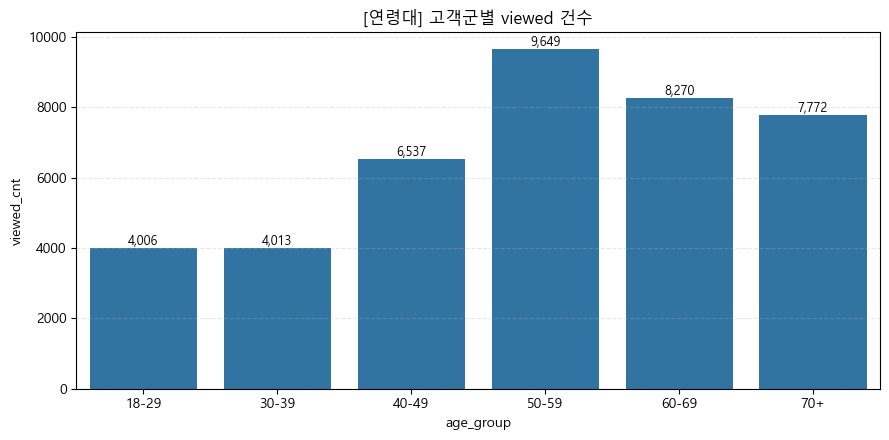

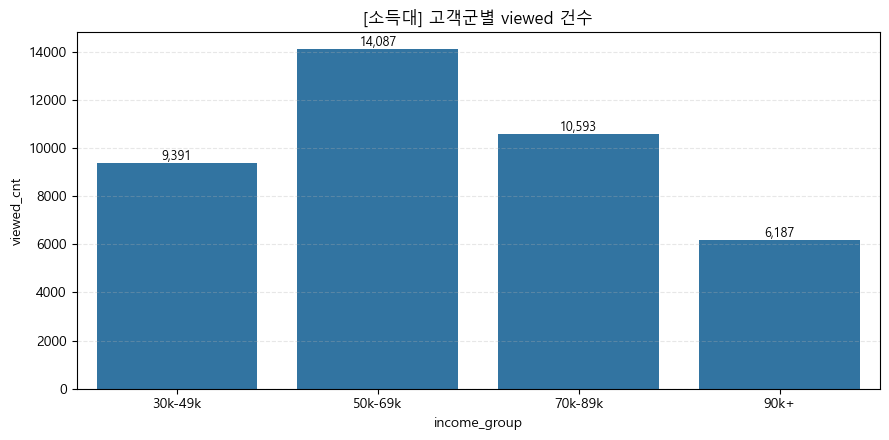

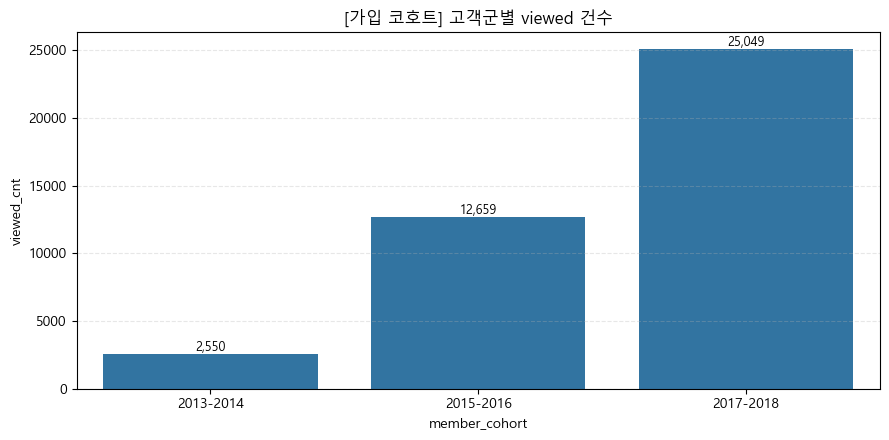

In [70]:
plot_segment_viewed_count(gender_vc_summary, 'gender_group', '성별', exclude_groups=['Missing'])
plot_segment_viewed_count(age_vc_summary, 'age_group', '연령대', exclude_groups=['Missing'])
plot_segment_viewed_count(income_vc_summary, 'income_group', '소득대', exclude_groups=['Missing'])
plot_segment_viewed_count(cohort_vc_summary, 'member_cohort', '가입 코호트', exclude_groups=['Missing'])

# 3. 어떤 고객군이 오퍼를 본 뒤 완료까지 더 잘 이어지는가?
종합 보고서

## 1. 성별 기준 해석
여성(F)의 열람 후 완료율은 **51.8%**, 남성(M)은 42.0%로 나타났다.\
즉, 오퍼를 한 번 본 뒤 실제 완료까지 이어지는 것은 여성 고객군이 더 강한 편이다.

오퍼 유형별로 보면\
`bogo`에서는 여성이 **58.0%**, 남성이 42.3%였고,\
`discount`에서도 여성이 **68.2%**, 남성이 61.3%로 여성이 더 높게 나타났다.

결론적으론,\
단순 열람률 차이보다도 열람 이후 행동 전환력 자체가 여성 쪽에서 더 높다고 해석할 수 있다.\
특히 bogo처럼 실제 조건 충족이 필요한 오퍼에서 성별 차이가 더 크게 나타났다는 점이 중요하다.

디민 O 그룹은 표본 수가 적고, Missing 그룹은 결측 정보의 영향이 커서
참고용으로만 보는 것이 적절하다.

## 2. 연령대 기준 해석
18–29세는 **37.0%**로 가장 낮았고,\
30–39세는 43.4%,\
40–49세는 45.4%,\
50–59세는 48.4%,\
60–69세는 47.9%,\
70세 이상은 **48.4%**로 나타났다.

잔체적으로 보면\
연령이 높아질수록 오퍼를 본 뒤 완료까지 이어지는 비율이 높아지는 흐름이 나타난다.

20대는 오퍼를 보더라도 실제 완료 행동으로 이어지는 비율이 낮은 편이고,\
50대 이상은 상대적으로 안정적으로 완료까지 이어지는 모습이다.

오퍼 유형별로 보면\
bogo의 열람 후 완료율은\
18–29세 **34.4%**에서 시작해\
50–59세 52.9%,\
70세 이상 **53.3%**까지 올라간다.\
discount도 18–29세 58.3%, 30–39세 64.0%, 50대 이상은 65% 안팎으로 더 높다.

결론적으론,\
젊은 층은 오퍼를 보더라도 실제 완료 행동까지 이어지는 힘이 약하고,\
중장년층은 열람 이후 행동 전환이 더 안정적이라는 뜻으로 해석할 수 있다.


## 3. 소득대 기준 해석
소득대별 열람 후 완료율 차이는 매우 뚜렷하게 나타났다.
- 30k–49k: 36.1%
- 50k–69k: 44.6%
- 70k–89k: 52.1%
- 90k+: 55.1%

소득 수준이 높을수록 오퍼를 본 뒤 완료까지 이어지는 비율도 함께 높아지는 경향이 분명하게 보인다.

오퍼 유형별로 보면\
bogo는 30k–49k에서 **32.8%**였지만\
90k+에서는 **64.2%**까지 올라간다.\
거의 두 배 가까운 차이다.

discount 역시 30k–49k는 58.4%,\
70k–89k는 68.4%,\
90k+는 **68.1%**로 더 높다.

결론적으론,\
저소득 고객군은 오퍼를 본 뒤에도 실제 완료까지 이어지는 비율이 낮고,\
중·고소득 고객군은 열람 이후 행동 전환력이 훨씬 강하다고 볼 수 있다.

즉, **고소득층일수록** 실제 혜택 활용이나 완료 행동으로 더 잘 이어진다.

## 4. 가입 코호트 기준 해석
가입 시점에 따라 열람 후 완료율은 큰 차이를 보였다.\
- 2013–2014 가입 고객: 46.1%
- 2015–2016 가입 고객: 59.9%
- 2017–2018 가입 고객: 39.2%

이 중에서 가장 높은 반응을 보인 것은 2015–2016 가입 고객군이었다.\
이는 오퍼를 본 뒤 거의 10명 중 6명 수준이 완료까지 이어졌다는 뜻한다.

오퍼 유형별로 보면\
bogo에서 2015–2016 가입 고객은 65.7%,\
2017–2018 가입 고객은 **41.9%**였다.

discount에서는\
2013–2014가 77.6%,\
2015–2016이 81.1%,\
2017–2018이 **54.4%**로 나타났다.

결론적으론,\
최근 가입자라고 해서 무조건 반응이 좋은 것은 아니며,\
특정 코호트에서 오히려 더 강한 완료 전환력이 나타난다.

특히나 2015–2016 가입 고객은 bogo, discount 모두에서 높은 성과를 보이며\
**가장 강한 핵심 반응층**으로 해석할 수 있다.

## 5. 종합분석
오퍼를 본 뒤 완료까지 더 잘 이어지는 고객군은 다음과 같이 정리할 수 있다.
- 성별 기준: 여성 고객군
- 연령 기준: 50대 이상 중장년층
- 소득 기준: 70k 이상, 특히 90k+ 고소득층
- 가입 시점 기준: 2015–2016 가입 고객군

전반적으로 젊은층과 저소득층은 오퍼를 보더라도 완료까지 이어지는 비율이 낮았고,\
중장년층·중고소득층은 열람 이후 실제 완료 행동까지 더 안정적으로 이어졌다.

또한 모든 주요 고객군에서 discount의 viewed → completed 전환률이 bogo보다 높게 나타나,\
열람 단계에서는 bogo가 강하지만 완료 단계에서는 discount가 더 강한 패턴이 확인되었다.

반대로 20대·저소득층·최근 가입 고객군은 열람 이후 완료 단계에서 왜 이탈하는지 별도로 점검할 필요가 있다.

따라서\
고객의 관심을 끄는 단계와 완료를 유도하는 단계를 분리해서 설계할 필요가 있으며,\
열람 유도에는 bogo, 완료 유도에는 discount 중심 전략을 고객군별로 조합해 운영하는 방향을 검토할 수 있다.

# 4. 어떤 프로모션 유형이 열람률·완료율 측면에서 더 성과가 좋은가?
프로모션 유형(`offer_type`)별 반응 성과를 비교

- 프로모션 유형
    - bogo
    - discount
    - informational

1. received 기준 성과\
오퍼를 받은 전체 건수 중 얼마나 열람되고 완료되었는가?

2. viewed 기준 성과\
오퍼를 실제로 본 건수 중 completed까지 얼마나 이어졌는가?

주의사항
`informational`은 구조상 completed 해석이 불가능함\
되도록 완료율 비교는 `bogo`, `discount` 중심으로 보는 것이 적절

## 프로모션 유형별 전체 반응률 요약표 생성

In [71]:
# ============================================================
# 1. 프로모션 유형별 전체 반응률 요약표
# ============================================================

offer_type_summary = (
    funnel_seg
    .groupby('offer_type', dropna=False)
    .agg(
        received_cnt=('customer_id', 'size'),
        viewed_cnt=('converted_rv', 'sum'),
        completed_cnt=('converted_rc', 'sum'),
        strict_completed_cnt=('converted_rvc', 'sum')
    )
    .reset_index()
)

offer_type_summary['rv_rate'] = (
    offer_type_summary['viewed_cnt'] / offer_type_summary['received_cnt'] * 100
)
offer_type_summary['rc_rate'] = (
    offer_type_summary['completed_cnt'] / offer_type_summary['received_cnt'] * 100
)
offer_type_summary['rvc_rate'] = (
    offer_type_summary['strict_completed_cnt'] / offer_type_summary['received_cnt'] * 100
)

offer_order = ['bogo', 'discount', 'informational']
offer_type_summary['offer_type'] = pd.Categorical(
    offer_type_summary['offer_type'],
    categories=offer_order,
    ordered=True
)
offer_type_summary = offer_type_summary.sort_values('offer_type').reset_index(drop=True)

print("=" * 70)
print("프로모션 유형별 전체 반응률 요약표")
print("=" * 70)
display(offer_type_summary)

프로모션 유형별 전체 반응률 요약표


,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,bogo,30499,25250,15501,11024,82.789600,50.824617,36.145447
1,discount,30543,21370,17651,12472,69.966932,57.790656,40.834234
2,informational,15235,9947,0,0,65.290450,0.000000,0.000000


## 프로모션 유형별 VC 요약표 생성

In [72]:
# ============================================================
# 2. 프로모션 유형별 viewed -> completed 전환률 요약표
# ============================================================

offer_type_vc_summary = (
    funnel_vc_main
    .groupby('offer_type', dropna=False)
    .agg(
        viewed_cnt=('customer_id', 'size'),
        completed_after_view_cnt=('converted_vc', 'sum'),
        avg_vc_time=('vc_time_diff', 'mean')
    )
    .reset_index()
)

offer_type_vc_summary['vc_rate'] = (
    offer_type_vc_summary['completed_after_view_cnt'] /
    offer_type_vc_summary['viewed_cnt'] * 100
)

offer_type_vc_summary['offer_type'] = pd.Categorical(
    offer_type_vc_summary['offer_type'],
    categories=['bogo', 'discount'],
    ordered=True
)
offer_type_vc_summary = offer_type_vc_summary.sort_values('offer_type').reset_index(drop=True)

print("=" * 70)
print("프로모션 유형별 viewed -> completed 전환률 요약표")
print("=" * 70)
display(offer_type_vc_summary)

프로모션 유형별 viewed -> completed 전환률 요약표


,offer_type,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,bogo,25250,11024,36.305334,43.659406
1,discount,21370,12472,53.567992,58.362190


## 3. 시각화

### 시각화 함수

In [74]:
def plot_offer_type_rv(summary_df):
    df_a = summary_df.copy()

    order_list = ['bogo', 'discount', 'informational']
    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=order_list,
        ordered=True
    )
    df_a = df_a.sort_values('offer_type')

    plt.figure(figsize=(8, 4.5))
    sns.barplot(data=df_a, x='offer_type', y='rv_rate')

    plt.title('프로모션 유형별 열람률 비교')
    plt.xlabel('offer_type')
    plt.ylabel('rv_rate (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    for i, v in enumerate(df_a['rv_rate']):
        plt.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

In [75]:
def plot_offer_type_completion_received(summary_df):
    df_a = summary_df.copy()
    df_a = df_a[df_a['offer_type'].isin(['bogo', 'discount'])].copy()

    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=['bogo', 'discount'],
        ordered=True
    )
    df_a = df_a.sort_values('offer_type')

    plot_df = df_a.melt(
        id_vars='offer_type',
        value_vars=['rc_rate', 'rvc_rate'],
        var_name='metric',
        value_name='rate'
    )

    metric_name_map = {
        'rc_rate': '완료율',
        'rvc_rate': '정상 퍼널 완료율'
    }
    plot_df['metric'] = plot_df['metric'].map(metric_name_map)

    plt.figure(figsize=(8, 4.8))
    sns.pointplot(
        data=plot_df,
        x='offer_type',
        y='rate',
        hue='metric',
        dodge=0.25,
        markers='o',
        linestyles='-'
    )

    plt.title('프로모션 유형별 received 기준 완료 성과 비교')
    plt.xlabel('offer_type')
    plt.ylabel('rate (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(title='')
    plt.tight_layout()
    plt.show()

In [77]:
def plot_offer_type_vc(summary_df):
    df_a = summary_df.copy()

    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=['bogo', 'discount'],
        ordered=True
    )
    df_a = df_a.sort_values('offer_type')

    plt.figure(figsize=(7, 4.5))
    sns.barplot(data=df_a, x='offer_type', y='vc_rate')

    plt.title('프로모션 유형별 viewed → completed 전환률 비교')
    plt.xlabel('offer_type')
    plt.ylabel('vc_rate (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    for i, v in enumerate(df_a['vc_rate']):
        plt.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

### 시각화

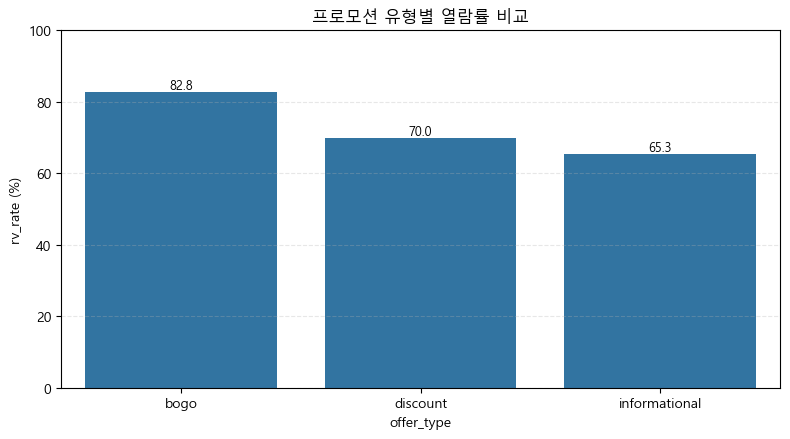

In [78]:
plot_offer_type_rv(offer_type_summary)

C:\Users\joon5\AppData\Local\Temp\ipykernel_8080\1675002570.py:5: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_a['offer_type'] = pd.Categorical(


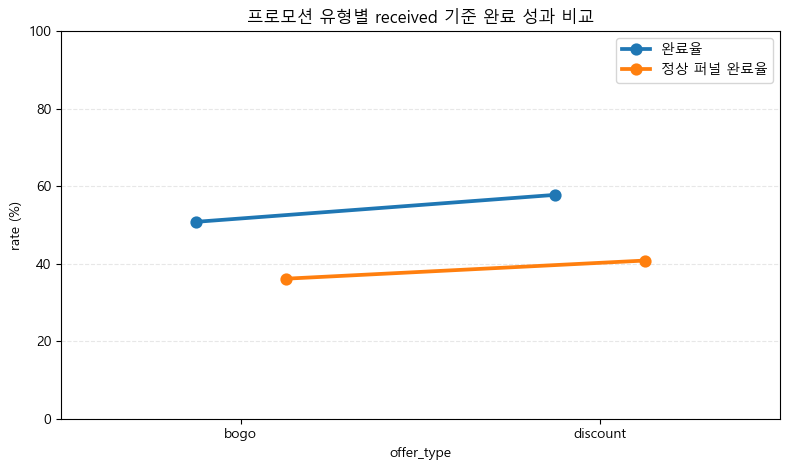

In [79]:
plot_offer_type_completion_received(offer_type_summary)

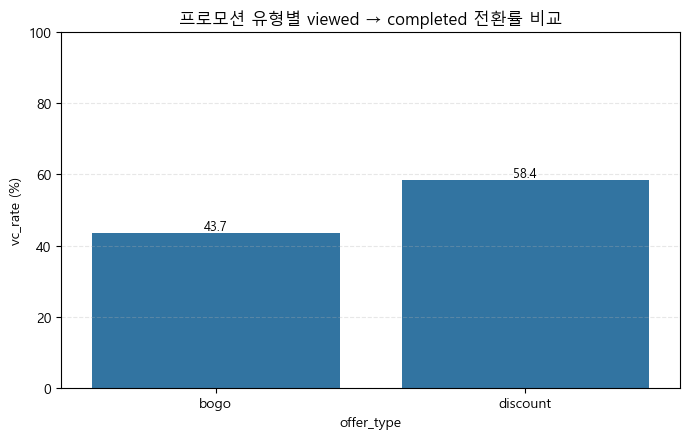

In [80]:
plot_offer_type_vc(offer_type_vc_summary)

# 4. 어떤 프로모션 유형이 열람률·완료율 측면에서 더 성과가 좋은가?
종합 보고서

## 1. 전체 수치 해석
- bogo
    - 열람률: 82.8%
    - 완료율: 50.8%
    - 정상 퍼널 완료율: 36.1%
- discount
    - 열람률: 70.0%
    - 완료율: 57.8%
    - 정상 퍼널 완료율: 40.8%
- informational
    - 열람률: 65.3%
    - 완료율: 0.0%
    - 정상 퍼널 완료율: 0.0%

### bogo
bogo는 열람률이 **82.8%**로 가장 높았다.\
이 수치는 고객들이 세 가지 유형 중에서 bogo 오퍼를 가장 자주 확인했다는 뜻이다.\
즉, 고객 반응의 첫 단계인 '보게 만드는 힘'에서는 가장 강한 유형이라고 볼 수 있다.\
다만 완료율은 50.8%, 정상 퍼널 완료율은 36.1%로 완료 단계에서는 discount보다 다소 낮았다.

따라서 bogo는 고객 주목을 끌고 반응을 시작하게 만드는 데 강하지만,\
최종 완료까지 안정적으로 이어지는 힘은 상대적으로 조금 약한 편이다.

### discount
discount는 열람률이 **70.0%**로 bogo보다 낮았다.\
하지만 완료율은 57.8%, 정상 퍼널 완료율은 **40.8%**로 가장 높았다.\
즉, 이 유형은 오퍼를 확인한 고객이 실제 행동까지 이어질 가능성이 가장 높은 유형이었다.

보는 비율 자체는 bogo보다 낮지만, 실제로 사용할 가능성은 더 높은 유형이라 해석할 수 있다.

### informational
informational은 열람률이 **65.3%**로 나타났고, 완료율과 정상 퍼널 완료율은 모두 **0%**였다.\
이 유형은 애초에 완료를 목표로 하는 프로모션이 아니라, 고객에게 정보를 전달하거나 노출하는 성격이 강하다.\
따라서 얼마나 잘 열람되었는가만 중심으로 해석하는 것이 적절하다.

## 2. 종합해석
프로모션 유형별 성과는 다음처럼 정리할 수 있다.
- 열람률 기준 최고 성과: bogo
- 완료율 기준 최고 성과: discount
- 정상 퍼널 완료율 기준 최고 성과: discount
- 정보 전달용 해석 대상: informational

즉, bogo는 고객의 관심을 끌고 오퍼를 보게 만드는 데 가장 강했고,\
discount는 실제 완료 행동까지 이어지게 만드는 데 가장 강했다.\
따라서 프로모션 목적에 따라 유형 선택이 달라져야 한다고 해석할 수 있다.

# 번외: 유형별 세부 오퍼 비교

In [92]:
# ============================================================
# offer_id 기준 세부 비교 요약표
# ============================================================
offer_detail_summary = (
    funnel_seg
    .groupby(['offer_type', 'offer_id'], dropna=False)
    .agg(
        received_cnt=('customer_id', 'size'),
        viewed_cnt=('converted_rv', 'sum'),
        completed_cnt=('converted_rc', 'sum'),
        strict_completed_cnt=('converted_rvc', 'sum')
    )
    .reset_index()
)

offer_detail_summary['rv_rate'] = offer_detail_summary['viewed_cnt'] / offer_detail_summary['received_cnt'] * 100
offer_detail_summary['rc_rate'] = offer_detail_summary['completed_cnt'] / offer_detail_summary['received_cnt'] * 100
offer_detail_summary['rvc_rate'] = offer_detail_summary['strict_completed_cnt'] / offer_detail_summary['received_cnt'] * 100

offer_detail_summary['offer_type'] = pd.Categorical(
    offer_detail_summary['offer_type'],
    categories=offer_order,
    ordered=True
)

offer_detail_summary = offer_detail_summary.sort_values(
    ['offer_type', 'rv_rate'],
    ascending=[True, False]
).reset_index(drop=True)

print("=" * 70)
print("offer_id 기준 세부 비교 요약표")
print("=" * 70)
display(offer_detail_summary)

offer_id 기준 세부 비교 요약표


,offer_type,offer_id,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0,7593,7235,3301,2751,95.285131,43.474253,36.230739
1,bogo,f19421c1d4aa40978ebb69ca19b0e20d,7571,7208,4262,3536,95.205389,56.293752,46.704530
2,bogo,ae264e3637204a6fb9bb56bc8210ddfd,7658,6679,3635,2613,87.215983,47.466701,34.121180
3,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9,7677,4128,4303,2124,53.771004,56.050541,27.667057
4,discount,fafdcd668e3743c1bb461111dcafc2a4,7597,7327,5251,4635,96.445966,69.119389,61.010925
5,discount,2298d6c36e964ae4a3e7e9706d1fb8c2,7646,7330,5108,4377,95.867120,66.806173,57.245619
6,discount,2906b810c7d4411798c6938adc9daaa5,7632,4061,3958,2128,53.210168,51.860587,27.882600
7,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7,7668,2652,3334,1332,34.585290,43.479395,17.370892
8,informational,5a8bc65990b245e5a138643cd4eb9837,7618,6149,0,0,80.716724,0.000000,0.000000
9,informational,3f207df678b143eea3cee63160fa8bed,7617,3798,0,0,49.862150,0.000000,0.000000


In [93]:
# ============================================================
# 유형별 열람률, 완료율 상위 오퍼
# ============================================================

# 유형별 열람률 상위 오퍼
top_offer_rv = (
    offer_detail_summary
    .sort_values(['offer_type', 'rv_rate'], ascending=[True, False])
    .groupby('offer_type')
    .head(3)
    .reset_index(drop=True)
)

# 유형별 완료율 상위 오퍼
top_offer_rc = (
    offer_detail_summary
    .sort_values(['offer_type', 'rc_rate'], ascending=[True, False])
    .groupby('offer_type')
    .head(3)
    .reset_index(drop=True)
)

print("=" * 70)
print("유형별 열람률 상위 오퍼")
print("=" * 70)
display(top_offer_rv)

print("=" * 70)
print("유형별 완료율 상위 오퍼")
print("=" * 70)
display(top_offer_rc)

유형별 열람률 상위 오퍼


,offer_type,offer_id,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0,7593,7235,3301,2751,95.285131,43.474253,36.230739
1,bogo,f19421c1d4aa40978ebb69ca19b0e20d,7571,7208,4262,3536,95.205389,56.293752,46.704530
2,bogo,ae264e3637204a6fb9bb56bc8210ddfd,7658,6679,3635,2613,87.215983,47.466701,34.121180
3,discount,fafdcd668e3743c1bb461111dcafc2a4,7597,7327,5251,4635,96.445966,69.119389,61.010925
4,discount,2298d6c36e964ae4a3e7e9706d1fb8c2,7646,7330,5108,4377,95.867120,66.806173,57.245619
5,discount,2906b810c7d4411798c6938adc9daaa5,7632,4061,3958,2128,53.210168,51.860587,27.882600
6,informational,5a8bc65990b245e5a138643cd4eb9837,7618,6149,0,0,80.716724,0.000000,0.000000
7,informational,3f207df678b143eea3cee63160fa8bed,7617,3798,0,0,49.862150,0.000000,0.000000


유형별 완료율 상위 오퍼


,offer_type,offer_id,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,bogo,f19421c1d4aa40978ebb69ca19b0e20d,7571,7208,4262,3536,95.205389,56.293752,46.704530
1,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9,7677,4128,4303,2124,53.771004,56.050541,27.667057
2,bogo,ae264e3637204a6fb9bb56bc8210ddfd,7658,6679,3635,2613,87.215983,47.466701,34.121180
3,discount,fafdcd668e3743c1bb461111dcafc2a4,7597,7327,5251,4635,96.445966,69.119389,61.010925
4,discount,2298d6c36e964ae4a3e7e9706d1fb8c2,7646,7330,5108,4377,95.867120,66.806173,57.245619
5,discount,2906b810c7d4411798c6938adc9daaa5,7632,4061,3958,2128,53.210168,51.860587,27.882600
6,informational,5a8bc65990b245e5a138643cd4eb9837,7618,6149,0,0,80.716724,0.000000,0.000000
7,informational,3f207df678b143eea3cee63160fa8bed,7617,3798,0,0,49.862150,0.000000,0.000000


# 번외: 유형별 세부 오퍼 비교
종합분석 추가 분석 필요함

## 1. BOGO 유형 내 세부 오퍼 비교
bogo 유형 안에서는 총 4개의 세부 오퍼가 존재했다.

가장 눈에 띄는 오퍼는\
보상 5 / 난이도 5 / 유효기간 5일 / web+email+mobile+social 조합 오퍼였다.\
이 오퍼는 열람률이 95.2%, 완료율이 56.3%, 정상 퍼널 완료율이 **46.7%**로 나타나 bogo 내에서 가장 안정적으로 좋은 성과를 보였다.

반면\
보상 10 / 난이도 10 / 유효기간 5일 / web+email+mobile+social 조합 오퍼도 열람률은 **95.3%**로 매우 높았으나,\
완료율은 43.5%, 정상 퍼널 완료율은 **36.2%**로 앞선 오퍼보다 낮았다.

같은 4채널 조합이라도 보상과 난이도가 함께 커진 오퍼가 반드시 더 좋은 반응을 만든 것은 아니었다.

종합하면 bogo 유형에서는\
보상 5 / 난이도 5 / 5일 / 4채널 조합 오퍼가 가장 균형 잡힌 성과를 보였다.
즉, 무조건 보상이 크고 조건이 큰 오퍼보다,\
상대적으로 단순하고 짧은 구조의 오퍼가 더 잘 반응한 것으로 해석할 수 있다.

## 2. Discount 유형 내 세부 오퍼 비교

가장 좋은 성과를 보인 것은\
보상 2 / 난이도 10 / 유효기간 10일 / web+email+mobile+social 조합 오퍼였다.\
이 오퍼는 열람률 96.4%, 완료율 69.1%, 정상 퍼널 완료율 **61.0%**로 전체 세부 오퍼 중에서도 매우 높은 수준의 성과를 보였다.\
즉, 고객이 거의 대부분 오퍼를 확인했고, 정상 흐름으로 완료까지 이어지는 비율도 60%를 넘었다.

반면\
보상 2 / 난이도 10 / 유효기간 7일 / web+email+mobile 조합 오퍼는\
열람률 53.2%, 완료율 51.9%, 정상 퍼널 완료율 **27.9%**로 성과가 확실히 낮아졌다.\
즉, 같은 discount 유형이어도 채널 구성과 유효기간이 달라지면 반응이 크게 달라질 수 있다는 점을 보여준다.

종합하면 discount 안에서는\
4채널 조합 + 비교적 무난한 난이도와 보상 구조를 가진 오퍼가 가장 좋은 성과를 보였고,\
채널이 줄어들거나 난이도가 지나치게 커진 오퍼는 반응이 약해졌다.

## 3. Informational 유형 내 세부 오퍼 비교
informational은 구조상 completed 개념이 없기 때문에, 세부 오퍼 비교도 열람률 중심으로 해석하는 것이 적절하다.

두 개의 세부 오퍼를 비교하면,\
유효기간 3일 / email+mobile+social 조합 오퍼는 열람률이 **80.7%**로 높게 나타났다.\
반면, 유효기간 4일 / web+email+mobile 조합 오퍼는 열람률이 **49.9%**에 그쳤다.

즉, informational 안에서는\
짧은 기간과 소셜 채널이 포함된 조합이 훨씬 더 잘 열람된 것으로 보인다.

## 4. 종합 해석

전체적으로 보면, 세부 오퍼 수준에서는 다음과 같은 패턴이 확인된다.

- bogo에서는\
보상 5 / 난이도 5 / 5일 / 4채널 조합 오퍼가 가장 균형 잡힌 성과를 보였다.

- discount에서는\
보상 2 / 난이도 10 / 10일 / 4채널 조합 오퍼가 가장 높은 성과를 보였다.

- informational에서는\
3일 / email+mobile+social 조합 오퍼가 더 높은 열람률을 보였다.

유형 평균만 보면 discount가 가장 강한 성과를 보였지만,\
세부적으로 들어가면 같은 유형 안에서도 성과 차이가 크게 나타났다.

# 최종 인사이트 정리

이번 분석은 스타벅스 프로모션 데이터를 바탕으로, 고객이 오퍼를 받은 뒤 실제로 열람하고 완료하는 반응 구조를 확인하는 데 목적이 있다.\
아래에서는 전체 퍼널 구조, 고객 세그먼트별 반응 차이, 채널 조합별 차이, 프로모션 유형별 성과, 세부 오퍼 비교 순서로 결과를 정리한다.

## 0. 전체 퍼널 요약
스타벅스 프로모션 데이터를 바탕으로, 고객이 오퍼를 받은 뒤 실제로 열람하고 완료하는 반응 구조를 확인하는 데 목적이 있다.\

전체 오퍼 수신은 76,277건이었고, 이 중 56,567건이 열람되어 전체 열람률은 74.16%였다.\
또한 정상 퍼널 기준으로 열람 이후 완료까지 이어진 건수는 23,496건으로, 최종 정상 퍼널 완료율은 30.80%였다.

이는 단순히 completed 발생 건수만 볼 것이 아닌, 실제 viewed를 거쳐 completed까지 이어진 정상 흐름을 기준으로 해석해야 함을 보여준다.\
따라서 이후 분석은 received → viewed → completed의 흐름을 기준으로 열람률과 정상 퍼널 완료율 중심으로 해석하였다.

In [94]:
overall_summary = pd.DataFrame({
    '구간': [
        'received',
        'viewed',
        'completed (received 기준)',
        'strict funnel completed'
    ],
    '건수': [
        len(funnel_seg),
        funnel_seg['converted_rv'].sum(),
        funnel_seg['converted_rc'].sum(),
        funnel_seg['converted_rvc'].sum()
    ]
})

overall_summary['비율(%)'] = [
    100.00,
    funnel_seg['converted_rv'].mean() * 100,
    funnel_seg['converted_rc'].mean() * 100,
    funnel_seg['converted_rvc'].mean() * 100
]

overall_summary['비율(%)'] = overall_summary['비율(%)'].round(2)

In [95]:
display(overall_summary)
display(completed_case_summary)

,구간,건수,비율(%)
0,received,76277,100.00
1,viewed,56567,74.16
2,completed (received 기준),33152,43.46
3,strict funnel completed,23496,30.80


,구분,건수,비율(%)
0,received 기준 completed 전체,33152,100.00
1,strict funnel completed,23496,70.87
2,viewed 없이 completed,5744,17.33
3,viewed는 있으나 completed가 더 빠른 경우,4105,12.38


## 1. 고객 세그먼트별 열람 반응
열람 단계에서는 성별보다 연령대와 소득대에서 차이가 더 크게 나타났다.

연령대 기준으로는 18–29세의 열람률이 68.1%로 가장 낮았고, 40–49세는 77.7%로 가장 높았다.\
50–59세와 60–69세도 각각 73.9%, 74.0% 수준으로 비교적 안정적인 열람 반응을 보였다

소득대 기준으로는 30k–49k 구간의 열람률이 67.0%로 가장 낮았고, 50k–69k는 77.2%, 70k–89k는 76.0%로 더 높은 반응을 보였다.\
즉, 오퍼를 실제로 보게 만드는 초기 주목 단계에서는 젊은 층과 저소득층의 반응이 상대적으로 약했고, 중장년층과 중소득 이상 구간에서 더 높은 열람 반응이 나타났다.

아래 요약표와 그래프는 이러한 세그먼트 차이를 보여주며, 동시에 세그먼트별로 어떤 오퍼 유형에서 반응이 높아지는지도 함께 확인할 수 있게 한다.

,age_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,18-29,7095,4829,68.062016,9.301624
1,30-39,6893,4888,70.912520,9.036800
2,40-49,10288,7993,77.692457,13.487683
3,50-59,15894,11748,73.914685,20.837212
4,60-69,13423,9931,73.984951,17.597703
5,70+,12885,9438,73.247963,16.892379
6,Missing,9799,7740,78.987652,12.846599


,income_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,30k-49k,16967,11368,67.000648,22.243927
1,50k-69k,22428,17313,77.193686,29.403359
2,70k-89k,16783,12752,75.981648,22.002701
3,90k+,10323,7410,71.781459,13.533568
4,Missing,9776,7724,79.009820,12.816445


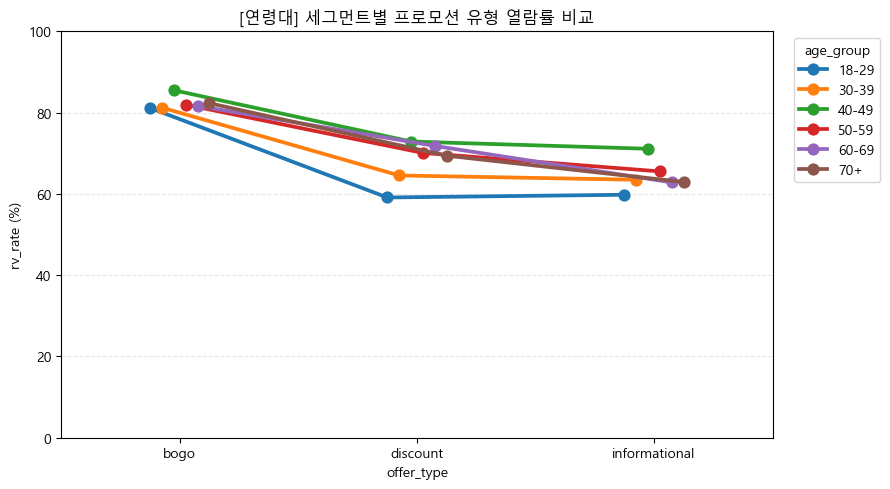

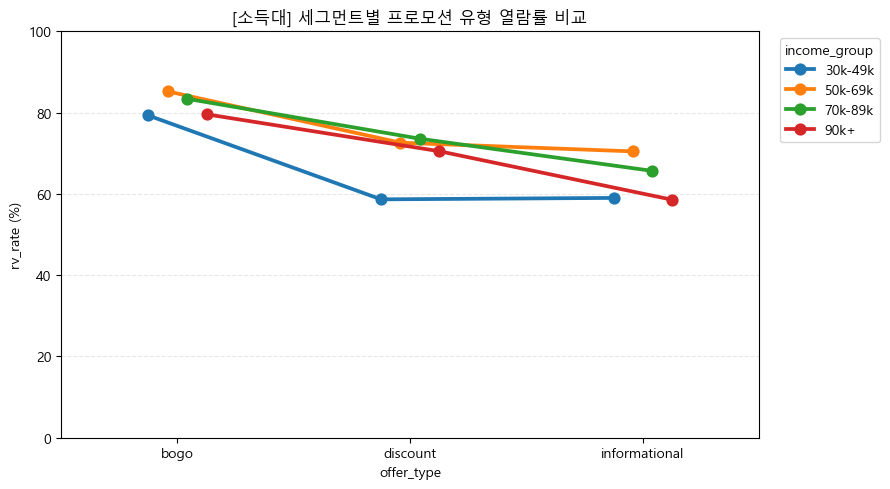

In [96]:
display(age_rv_summary)
display(income_rv_summary)

plot_segment_offer_point(age_offer_rv_summary, 'age_group', '연령대', exclude_groups=['Missing'])
plot_segment_offer_point(income_offer_rv_summary, 'income_group', '소득대', exclude_groups=['Missing'])

## 2. 채널 조합별 오퍼 반응 차이
채널 조합에 따라 오퍼 반응률은 뚜렷하게 달라졌다.

가장 성과가 높았던 조합은 web + email + mobile + social의 4채널 조합이었다.\
이 조합은 열람률이 95.7%, 정상 퍼널 완료율이 50.3%로 전체 채널 조합 중 가장 높은 성과를 보였다.

반면 web + email + mobile 조합은 열람률 52.3%, 정상 퍼널 완료율 18.5%였고,\
email + mobile + social 조합은 열람률 84.0%로 높았지만 정상 퍼널 완료율은 17.1%에 그쳤다.\
web + email 조합은 열람률 34.6%, 정상 퍼널 완료율 17.4%로 가장 약한 수준이었다.

즉, 채널을 복합적으로 활용한 조합에서 고객의 열람과 완료가 모두 더 잘 일어나는 경향이 확인되었다.\
다만 이 결과는 채널 자체의 순수 효과라기보다, 실제 운영된 오퍼-채널 조합 안에서 어떤 패턴이 가장 강했는지로 해석하는 것이 적절하다.

,channel_combo,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,web + email + mobile + social,30407,29100,17922,15299,95.701648,58.940376,50.314072
1,web + email + mobile,22926,11987,8261,4252,52.285615,36.033325,18.546628
2,email + mobile + social,15276,12828,3635,2613,83.974863,23.795496,17.105263
3,web + email,7668,2652,3334,1332,34.585290,43.479395,17.370892


,channel_combo,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,email + mobile + social,bogo,7658,6679,3635,2613,87.215983,47.466701,34.121180
1,email + mobile + social,informational,7618,6149,0,0,80.716724,0.000000,0.000000
2,web + email,discount,7668,2652,3334,1332,34.585290,43.479395,17.370892
3,web + email + mobile,bogo,7677,4128,4303,2124,53.771004,56.050541,27.667057
4,web + email + mobile,discount,7632,4061,3958,2128,53.210168,51.860587,27.882600
5,web + email + mobile,informational,7617,3798,0,0,49.862150,0.000000,0.000000
6,web + email + mobile + social,bogo,15164,14443,7563,6287,95.245318,49.874703,41.460037
7,web + email + mobile + social,discount,15243,14657,10359,9012,96.155612,67.959063,59.122220


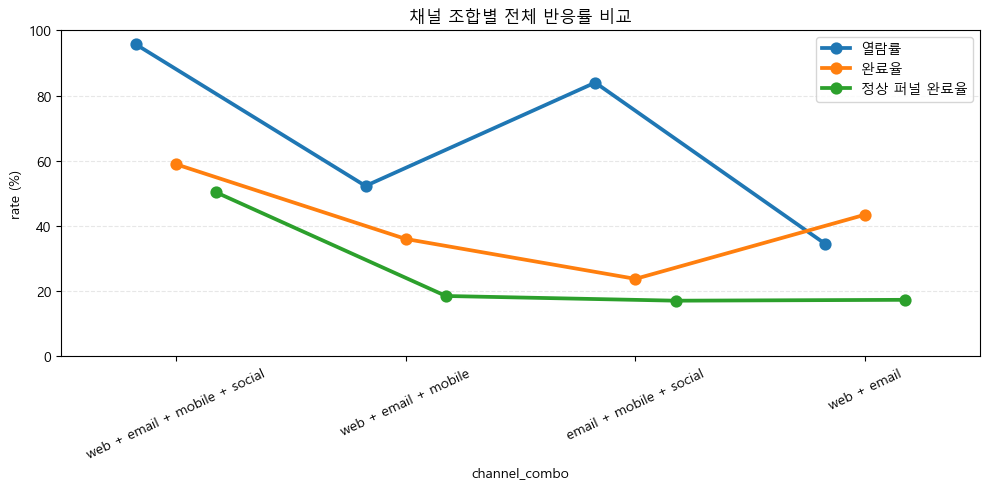

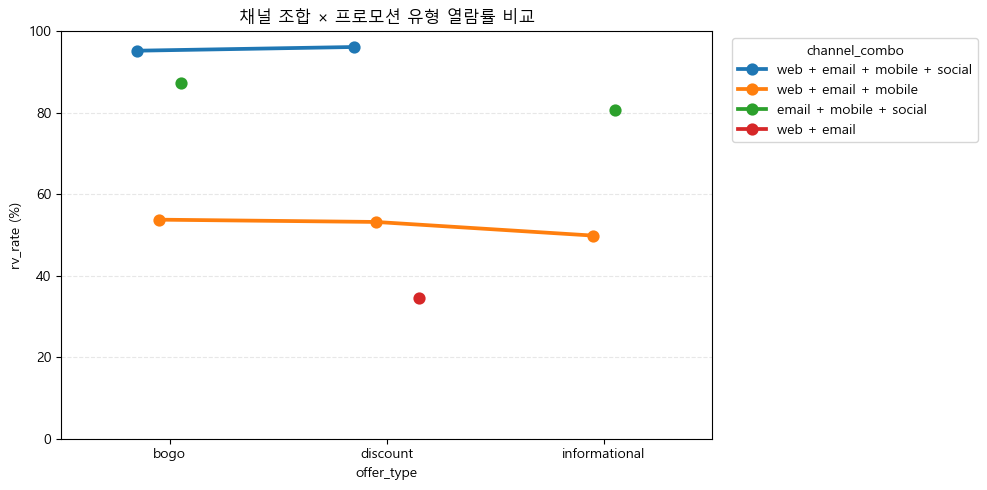

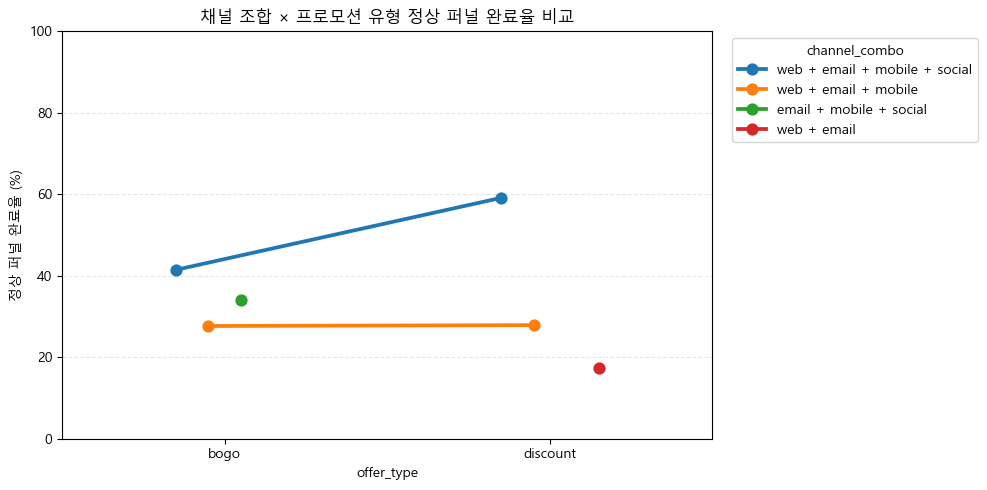

In [97]:
display(channel_summary)
display(channel_offer_summary)

plot_channel_metric_compare(channel_summary)
plot_channel_offer_rv(channel_offer_summary)
plot_channel_offer_completion(channel_offer_summary, 'rvc_rate')

## 3. 고객군별 viewed → completed 전환
열람 이후 실제 완료까지 이어지는 전환력은 고객군에 따라 차이가 더 뚜렷하게 나타났다.

성별 기준으로는 여성의 viewed → completed 전환율이 62.7%로, 남성 50.9%보다 높았다.\
연령대 기준으로는 18–29세가 44.6%로 가장 낮았고, 50–59세는 58.9%, 70세 이상은 58.8%로 더 높은 전환력을 보였다.

소득대 기준으로는 30k–49k 구간이 43.7%로 가장 낮았고,\
70k–89k는 62.7%, 90k+는 66.0%로 높은 전환율을 보였다.\
즉, 소득 수준이 높은 고객일수록 오퍼를 본 뒤 실제 완료로 이어질 가능성이 더 컸다.

가입 코호트 기준으로는 2015–2016 가입 고객의 viewed → completed 전환율이 72.7%로 가장 높았고,\
2017–2018 가입 고객은 47.6%로 상대적으로 낮았다.\
이는 열람 이후 실제 행동까지 이어지는 힘이 기존 가입 고객층에서 더 강하게 나타났음을 보여준다.

결국 열람을 유도하는 고객군과, 열람 이후 완료까지 잘 이어지는 고객군은 완전히 같지 않았으며, 완료 전략은 별도로 설계할 필요가 있다.

,gender_group,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,M,22881,11655,47.171686,50.937459
1,F,16765,10507,40.514133,62.672234
2,Missing,6362,944,81.165254,14.838101
3,O,612,390,41.646154,63.725490


,age_group,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,50-59,9649,5682,42.248152,58.886931
1,60-69,8270,4761,44.514178,57.569528
2,70+,7772,4570,42.771991,58.800823
3,40-49,6537,3627,44.689826,55.484167
4,Missing,6373,952,80.722689,14.938020
5,30-39,4013,2119,45.227938,52.803389
6,18-29,4006,1785,48.235294,44.558163


,income_group,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,50k-69k,14087,7720,45.780311,54.802300
1,70k-89k,10593,6641,41.379310,62.692344
2,30k-49k,9391,4107,50.100804,43.733362
3,Missing,6362,944,81.165254,14.838101
4,90k+,6187,4084,38.619491,66.009374


,member_cohort,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,2017-2018,25049,11916,48.594159,47.570761
1,2015-2016,12659,9209,36.243675,72.746662
2,Missing,6362,944,81.165254,14.838101
3,2013-2014,2550,1427,55.286615,55.960784


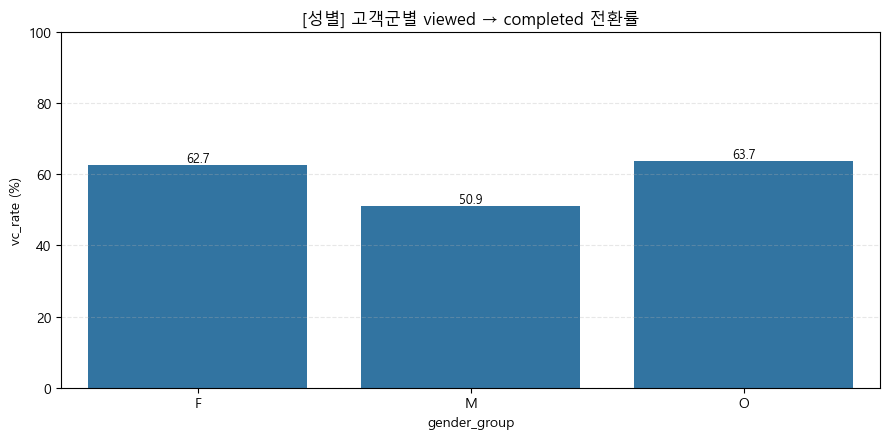

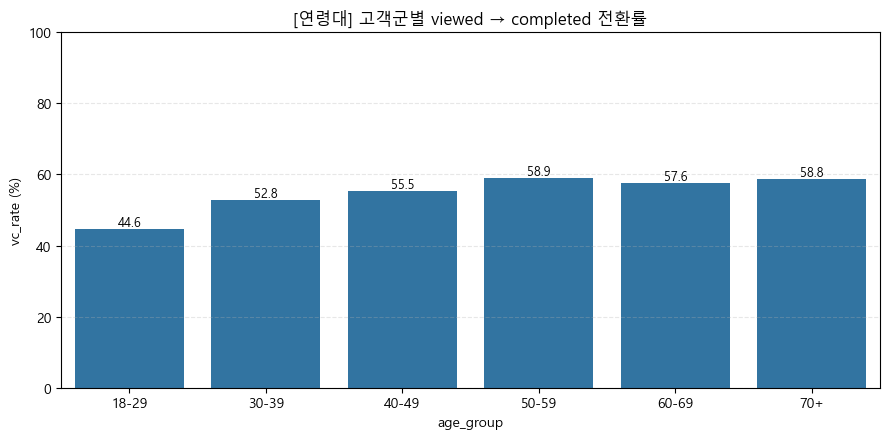

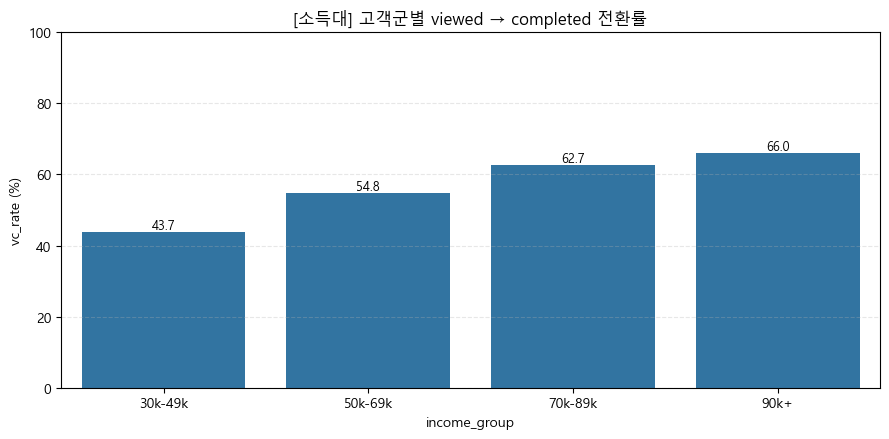

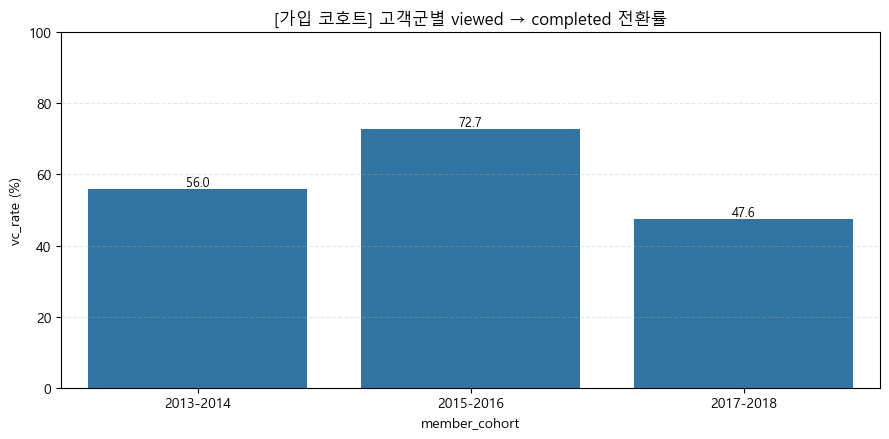

In [98]:
display(gender_vc_summary)
display(age_vc_summary)
display(income_vc_summary)
display(cohort_vc_summary)

plot_segment_vc_bar(gender_vc_summary, 'gender_group', '성별', exclude_groups=['Missing'])
plot_segment_vc_bar(age_vc_summary, 'age_group', '연령대', exclude_groups=['Missing'])
plot_segment_vc_bar(income_vc_summary, 'income_group', '소득대', exclude_groups=['Missing'])
plot_segment_vc_bar(cohort_vc_summary, 'member_cohort', '가입 코호트', exclude_groups=['Missing'])

## 4. 프로모션 유형별 성과 비교
프로모션 유형별 성과를 비교한 결과, 열람 유도에 강한 유형과 완료 유도에 강한 유형이 서로 다르게 나타났다.

bogo는 열람률이 82.8%로 가장 높아 고객의 관심을 끌고 오퍼를 실제로 보게 만드는 힘이 가장 컸다.\
반면 discount의 열람률은 70.0%로 bogo보다 낮았지만, 정상 퍼널 완료율은 40.8%로 가장 높았다.\
또한 viewed 이후 completed 전환율도 discount가 58.4%로, bogo의 43.7%보다 높았다.\
informational은 열람률 65.3%로 노출·인지 목적에서는 의미가 있었지만, 완료 지표로 평가하는 유형은 아니었다.

즉, bogo는 주목 유도에 강한 오퍼이고, discount는 실제 완료 유도에 더 강한 오퍼라고 해석할 수 있다.\
따라서 프로모션 유형은 하나의 공통 기준으로 평가하기보다, 각 유형이 담당하는 역할을 구분해서 해석하는 것이 적절하다.

,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,bogo,30499,25250,15501,11024,82.789600,50.824617,36.145447
1,discount,30543,21370,17651,12472,69.966932,57.790656,40.834234
2,informational,15235,9947,0,0,65.290450,0.000000,0.000000


,offer_type,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,bogo,25250,11024,36.305334,43.659406
1,discount,21370,12472,53.567992,58.362190


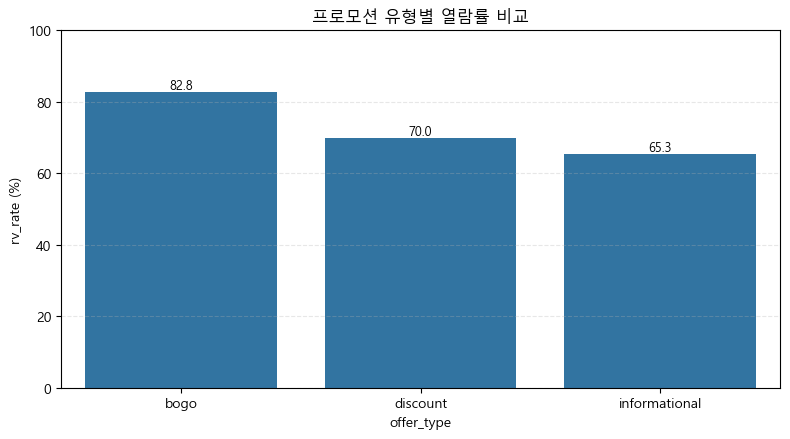

C:\Users\joon5\AppData\Local\Temp\ipykernel_8080\1675002570.py:5: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_a['offer_type'] = pd.Categorical(


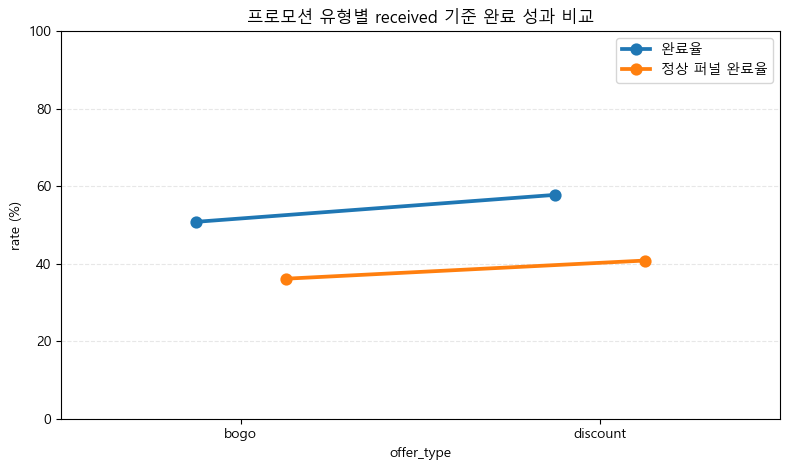

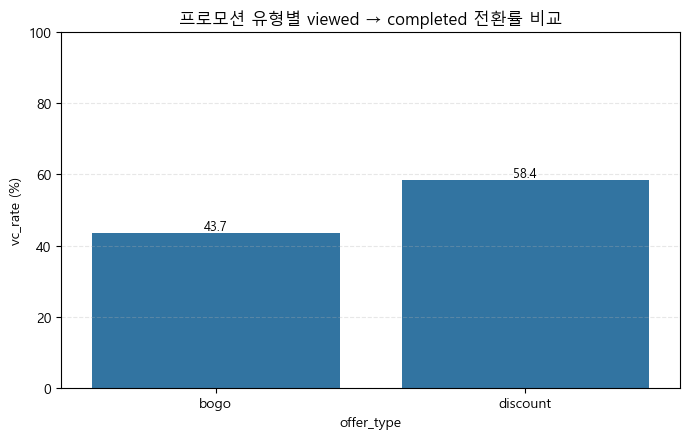

In [99]:
display(offer_type_summary)
display(offer_type_vc_summary)

plot_offer_type_rv(offer_type_summary)
plot_offer_type_completion_received(offer_type_summary)
plot_offer_type_vc(offer_type_vc_summary)

## 5. 유형별 세부 오퍼 비교
같은 프로모션 유형 안에서도 세부 오퍼별 성과 차이는 뚜렷하게 나타났다.

먼저 bogo 유형은 정상 퍼널 완료율이 27.7%에서 46.7%까지 분포해, 같은 bogo 안에서도 오퍼별 성과 차이가 존재했다.\
가장 높은 성과를 보인 오퍼는 46.7%였고, 가장 낮은 오퍼는 27.7%로 약 19.0%p 차이가 발생했다.

discount 유형은 세부 오퍼별 편차가 더 크게 나타났다.\
가장 높은 오퍼의 정상 퍼널 완료율은 61.0%, 그다음은 57.2%였지만, 일부 오퍼는 27.9%, 17.4% 수준에 머물렀다.\
즉, 같은 discount 유형이라도 어떤 오퍼는 매우 강한 전환 성과를 보인 반면, 어떤 오퍼는 상대적으로 낮은 반응에 그쳤다.

informational 유형은 완료보다 열람 중심으로 해석하는 것이 적절한데, 이 역시 오퍼별 차이가 확인되었다.\
가장 높은 오퍼의 열람률은 80.7%였지만, 가장 낮은 오퍼는 49.9%로 약 30.8%p의 차이를 보였다.

결국 세부 오퍼 비교 결과는, 단순히 프로모션 유형만으로 성과를 판단하기 어렵다는 점을 보여준다.\ 
같은 유형 안에서도 보상 수준, 난이도, 유효기간, 채널 조합에 따라 반응률 차이가 발생했으며,\
따라서 최종 전략은 유형 수준에서 끝나는 것이 아니라 실제 성과가 검증된 세부 오퍼 단위까지 함께 고려할 필요가 있다.

In [ ]:
top_bogo = (
    offer_detail_summary[offer_detail_summary['offer_type'] == 'bogo']
    .sort_values('rvc_rate', ascending=False)
)

top_discount = (
    offer_detail_summary[offer_detail_summary['offer_type'] == 'discount']
    .sort_values('rvc_rate', ascending=False)
)

top_info = (
    offer_detail_summary[offer_detail_summary['offer_type'] == 'informational']
    .sort_values('rv_rate', ascending=False)
)

display(top_bogo[['offer_id', 'received_cnt', 'rv_rate', 'rc_rate', 'rvc_rate']])
display(top_discount[['offer_id', 'received_cnt', 'rv_rate', 'rc_rate', 'rvc_rate']])
display(top_info[['offer_id', 'received_cnt', 'rv_rate', 'rc_rate']])

,offer_id,received_cnt,rv_rate,rc_rate,rvc_rate
1,f19421c1d4aa40978ebb69ca19b0e20d,7571,95.205389,56.293752,46.704530
0,4d5c57ea9a6940dd891ad53e9dbe8da0,7593,95.285131,43.474253,36.230739
2,ae264e3637204a6fb9bb56bc8210ddfd,7658,87.215983,47.466701,34.121180
3,9b98b8c7a33c4b65b9aebfe6a799e6d9,7677,53.771004,56.050541,27.667057


,offer_id,received_cnt,rv_rate,rc_rate,rvc_rate
4,fafdcd668e3743c1bb461111dcafc2a4,7597,96.445966,69.119389,61.010925
5,2298d6c36e964ae4a3e7e9706d1fb8c2,7646,95.867120,66.806173,57.245619
6,2906b810c7d4411798c6938adc9daaa5,7632,53.210168,51.860587,27.882600
7,0b1e1539f2cc45b7b9fa7c272da2e1d7,7668,34.585290,43.479395,17.370892


,offer_id,received_cnt,rv_rate,rc_rate
8,5a8bc65990b245e5a138643cd4eb9837,7618,80.716724,0.0
9,3f207df678b143eea3cee63160fa8bed,7617,49.862150,0.0


## 6. 최종 인사이트
이번 분석을 종합하면, 스타벅스 프로모션은 모든 고객에게 동일하게 작동하지 않았고,\
열람을 끌어내는 단계와 완료까지 이어지게 만드는 단계에서도 효과적인 전략이 서로 달랐다.

1. 열람 단계에서는 성별보다 연령대와 소득대 차이가 더 크게 나타났다.\
특히 20대와 저소득층은 열람 반응이 상대적으로 낮았고, 중장년층과 중소득 이상 고객군에서 더 높은 열람 반응이 나타났다.

2. viewed 이후 completed까지 이어지는 전환력은 여성, 50대 이상, 70k 이상 고소득층, 그리고 2015–2016 가입 코호트에서 더 높게 나타났다.\
즉, 오퍼를 보게 만드는 고객군과 실제 완료까지 잘 이어지는 고객군은 같지 않았다.

3. 프로모션 유형별로는 bogo가 열람 유도에 가장 강했고, discount는 완료 유도에 가장 강했다.\
또한 채널 조합과 세부 오퍼 수준에서도 성과 차이가 뚜렷하게 나타나, 단순히 한 가지 유형을 전체 고객에게 일괄 적용하는 방식은 비효율적일 수 있음을 확인했다.

따라서 향후 프로모션 전략은 모든 고객에게 동일한 오퍼를 일괄 제공하기보다,\
저반응 고객군(20대, 저소득층, 최근 가입층)에는 먼저 열람 반응을 높일 수 있는 주목 유도형 오퍼를 적용하고,\
고반응 고객군(중장년층, 중고소득층, 2015–2016 가입층)에는 실제 완료 전환력이 높은 오퍼를 중심으로 운영하는
방식이 더 효과적이라고 해석할 수 있다.

정리하면,\
**누가 오퍼를 잘 보는가**와 **누가 오퍼를 본 뒤 실제 완료까지 잘 이어지는가**를 분리해서 이해해야 하고,\  
이에 맞춰 고객 세그먼트별·유형별·채널별로 차등 전략을 설계해야 한다.
